# Benchmark universel — Détection de rythme et de mouvement v13
Fonctionne pour tout mouvement périodique. Supporte les sémantiques **position_extreme**, **position_crossing** et **motion_energy**.

**Guide rapide SIGNAL_SEMANTICS**
| La vérité terrain marque... | SIGNAL_SEMANTICS | SIGNAL_AXIS | INVERT_SIGNAL |
|---|---|---|---|
| Membre à la position la plus à gauche (floss, swing) | `position_extreme` | `x` | `True` |
| Membre à la position la plus à droite | `position_extreme` | `x` | `False` |
| Pied touche le sol (tap, step) | `position_extreme` | `y` | `False` |
| Retour à un angle de face donné (spin) | `position_extreme` | `x` | selon direction |
| Moment de vitesse maximale (chest pop, stomp) | `motion_energy` | `both` | `False` |
| Membre passe par le centre (bounce, kick) | `position_crossing` | `x` ou `y` | `False`=bas `True`=haut |

> **ViT et MiDaS** produisent toujours un signal `motion_energy`.
> Ignorés automatiquement si `SIGNAL_SEMANTICS != 'motion_energy'`, sauf si `FORCE_ALL_METHODS = True`.

## Cellule 1 — Installation
Exécuter une seule fois, puis **Runtime → Redémarrer la session**.

In [55]:
!pip install -q mediapipe scikit-learn tqdm
!pip install -q torch torchvision timm
print("Terminé — redémarrer la session puis exécuter depuis la cellule 2")


Terminé — redémarrer la session puis exécuter depuis la cellule 2


## Cellule 2 — Imports

In [56]:
import os, time, warnings, io, base64
import cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter, detrend as sp_detrend
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
from IPython.display import display, HTML
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi':110,'figure.facecolor':'#0f1117',
    'axes.facecolor':'#1a1d27','text.color':'#ecf0f1',
    'axes.labelcolor':'#ecf0f1','xtick.color':'#ecf0f1',
    'ytick.color':'#ecf0f1','axes.edgecolor':'#444',
})
try:
    import torch, torchvision, torchvision.transforms as T
    from torchvision.models.optical_flow import raft_small, Raft_Small_Weights
    _TORCH=True; DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
    print(f'PyTorch {torch.__version__}  device={DEVICE}')
except ImportError:
    _TORCH=False; DEVICE='cpu'; print('PyTorch non trouvé')
try:
    import timm; _TIMM=True; print(f'timm {timm.__version__}')
except ImportError:
    _TIMM=False; print('timm non trouvé')
try:
    import mediapipe as mp
    from mediapipe.tasks import python as _mp_tasks
    from mediapipe.tasks.python import vision as _mp_vision
    _MP=True; print(f'MediaPipe {mp.__version__} ok')
except ImportError:
    _MP=False; print('MediaPipe non trouvé')
try:
    from sklearn.metrics import roc_auc_score, roc_curve
    _SKLEARN=True; print('scikit-learn ok')
except ImportError:
    _SKLEARN=False
print('Imports effectués')


PyTorch 2.10.0+cu128  device=cuda
timm 1.0.26
MediaPipe 0.10.35 ok
scikit-learn ok
Imports effectués


## Cellule 3 — Chargement vidéo et vérité terrain CSV

In [57]:
from google.colab import files as _gfiles
print('Charger la vidéo :')
_uv = _gfiles.upload()
VIDEO_PATH = f"/content/{list(_uv.keys())[0]}"
with open(VIDEO_PATH,'wb') as f: f.write(list(_uv.values())[0])
print(f'Vidéo : {VIDEO_PATH}')
print('Charger ground_truth.csv :')
_ug = _gfiles.upload()
GT_PATH = '/content/ground_truth.csv'
with open(GT_PATH,'wb') as f: f.write(list(_ug.values())[0])
_gt_df = pd.read_csv(GT_PATH)
_col = 'frame_peak' if 'frame_peak' in _gt_df.columns else _gt_df.columns[1]
GT_PEAKS = sorted(_gt_df[_col].dropna().astype(int).tolist())
print(f'GT : {len(GT_PEAKS)} événements')
display(_gt_df)


Charger la vidéo :


Saving jumping rope.mp4 to jumping rope.mp4
Vidéo : /content/jumping rope.mp4
Charger ground_truth.csv :


Saving ground_truth_Jumping_Rope.csv to ground_truth_Jumping_Rope.csv
GT : 11 événements


,event_id,frame_peak,time_sec
0,1,61,1.017
1,2,91,1.517
2,3,126,2.100
3,4,156,2.600
4,5,186,3.100
5,6,211,3.517
6,7,241,4.017
7,8,266,4.433
8,9,296,4.933
9,10,321,5.350


## Cellule 4 — Configuration par vidéo
Seule cellule à modifier entre deux vidéos.

In [58]:
EVENT_LABEL   = 'jump'
# 'spin' | 'beat' | 'step' | 'rep' | 'chest_pop' | 'kick' | 'jump' | 'floss' | 'foot_tap'

MOTION_TYPE   = 'impact'
# 'auto'        — déduit depuis la période GT
# 'fast_cyclic' — spinning, headspins (période < 0.5s)
# 'slow_cyclic' — biceps curls, squats (période > 1.0s)
# 'impact'      — chest pops, stomps (impulsion brève)
# 'lateral'     — waacking, balancements (dominante horizontale)
# 'continuous'  — tai chi, flux lent (pas de pic clair)

SIGNAL_SEMANTICS = 'position_extreme'
# 'motion_energy'    — pic quand le corps se déplace le plus vite
#                      adapté à : chest pops, stomps, sauts, impacts
# 'position_extreme' — pic quand un membre atteint sa position extrême
#                      adapté à : spins, floss, balancements
# 'position_crossing'— détecte le passage par un point neutre
#                      adapté à : foot taps, bounces, kicks

SIGNAL_AXIS   = 'y'
# 'x' (horizontal) | 'y' (vertical) | 'both' (magnitude, uniquement motion_energy)
# position_extreme + balancements gauche/droite/spins -> 'x'
# position_extreme + foot taps / sauts                -> 'y'

INVERT_SIGNAL = False
# True  = les événements GT sont des vallées dans le signal brut
# Exemples :
#   floss pic gauche, SIGNAL_AXIS='x'  -> True  (gauche = petit X)
#   spin retour face droite            -> False (droite = grand X)
#   foot tap, SIGNAL_AXIS='y'          -> False (sol = grand Y, pic naturel)
#   position_crossing passage montant  -> True

FORCE_ALL_METHODS = False
# False = ignorer ViT/MiDaS si SIGNAL_SEMANTICS != 'motion_energy' (recommandé)
# True  = tout exécuter (comparaison exhaustive)

print(f'Config : {EVENT_LABEL!r}  motion={MOTION_TYPE}  semantics={SIGNAL_SEMANTICS}')
print(f'         axis={SIGNAL_AXIS}  invert={INVERT_SIGNAL}  force_all={FORCE_ALL_METHODS}')


Config : 'jump'  motion=impact  semantics=position_extreme
         axis=y  invert=False  force_all=False


## Cellule 5 — Région d'intérêt
Sélectionner la partie du corps à analyser.

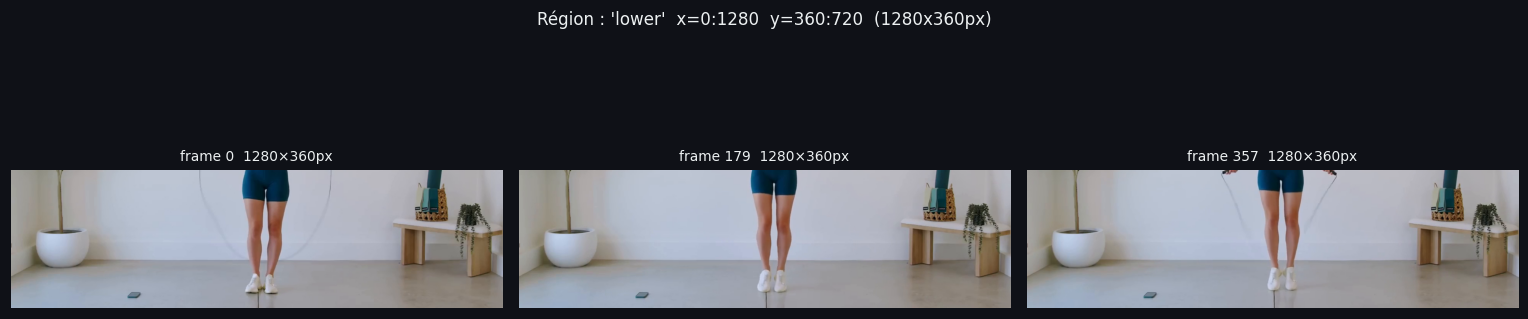

Région 'lower' — 1280x360px  (50% de la frame)


In [59]:
# Région à analyser :
#   "full"      — frame entière (défaut)
#   "upper"     — moitié supérieure (bras, tête, torse)
#   "lower"     — moitié inférieure (jambes, pieds)
#   "head"      — 25% supérieur
#   "torso"     — tiers central
#   "legs"      — 40% inférieur
#   "feet"      — 25% inférieur (nécessite une frame suffisamment haute)
#   "left"      — moitié gauche
#   "right"     — moitié droite
#   "left_arm"  — quart supérieur gauche
#   "right_arm" — quart supérieur droit
#   "left_leg"  — quart inférieur gauche
#   "right_leg" — quart inférieur droit
#   "center"    — 50% central en largeur, hauteur totale
#
REGION = "lower"


_cap = cv2.VideoCapture(VIDEO_PATH)
_, _f = _cap.read(); _cap.release()
_H, _W = _f.shape[:2]

_REGIONS = {
    "full":       (0,           0,           _W,         _H),
    "upper":      (0,           0,           _W,         _H//2),
    "lower":      (0,           _H//2,       _W,         _H),
    "head":       (0,           0,           _W,         _H//4),
    "torso":      (0,           _H//4,       _W,         2*_H//3),
    "legs":       (0,           int(_H*.55), _W,         _H),
    "feet":       (0,           int(_H*.72), _W,         _H),
    "left":       (0,           0,           _W//2,      _H),
    "right":      (_W//2,       0,           _W,         _H),
    "left_arm":   (0,           0,           _W//2,      _H//2),
    "right_arm":  (_W//2,       0,           _W,         _H//2),
    "left_leg":   (0,           _H//2,       _W//2,      _H),
    "right_leg":  (_W//2,       _H//2,       _W,         _H),
    "center":     (_W//4,       0,           3*_W//4,    _H),
}

if REGION not in _REGIONS:
    print(f"Région inconnue '{REGION}' — utilisation de 'full'")
    REGION = "full"

_x0, _y0, _x1, _y1 = _REGIONS[REGION]

# Taille minimale : 80px en hauteur et largeur
_MIN = 80
_crop_w = _x1 - _x0
_crop_h = _y1 - _y0

if _crop_h < _MIN:
    _extra  = (_MIN - _crop_h) // 2
    _y0     = max(0, _y0 - _extra)
    _y1     = min(_H, _y1 + _extra)
    _crop_h = _y1 - _y0
    print(f"AVERTISSEMENT : région trop courte — agrandie verticalement à {_crop_h}px")

if _crop_w < _MIN:
    _extra  = (_MIN - _crop_w) // 2
    _x0     = max(0, _x0 - _extra)
    _x1     = min(_W, _x1 + _extra)
    _crop_w = _x1 - _x0
    print(f"AVERTISSEMENT : région trop étroite — agrandie horizontalement à {_crop_w}px")

CROP = (_x0, _y0, _x1, _y1)

def apply_region(frame):
    """Recadre la frame selon la région sélectionnée."""
    x0, y0, x1, y1 = CROP
    cropped = frame[y0:y1, x0:x1]
    if cropped.size == 0:
        return frame  # fallback frame entière si crop vide
    return cropped

# Aperçu sur 3 frames représentatives
_cap = cv2.VideoCapture(VIDEO_PATH)
_n   = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor("#0f1117")
for ax, fi in zip(axes, [0, _n//2, max(0, _n-2)]):
    _cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
    _, _frame = _cap.read()
    if _frame is not None:
        crop = apply_region(_frame)
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"frame {fi}  {crop.shape[1]}×{crop.shape[0]}px",
                     color="#ecf0f1", fontsize=9)
    ax.axis("off")
_cap.release()
plt.suptitle(f"Région : '{REGION}'  x={_x0}:{_x1}  y={_y0}:{_y1}  ({_crop_w}x{_crop_h}px)",
             color="#ecf0f1", fontsize=11)
plt.tight_layout(); plt.show()

print(f"Région '{REGION}' — {_crop_w}x{_crop_h}px  ({_crop_w*_crop_h/(_W*_H)*100:.0f}% de la frame)")
if _crop_h < 120:
    print(f"AVERTISSEMENT : seulement {_crop_h}px de hauteur — flux optique potentiellement bruité. Essayer 'lower' ou 'legs'.")


## Cellule 6 — Utilitaires signal

In [60]:
def to_gray(f): return cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)

def moving_average(sig, w):
    if w<=1 or len(sig)<2: return sig.copy()
    k=np.ones(min(w,len(sig)))/min(w,len(sig))
    return np.convolve(sig, k, mode='same')

def savgol_smooth(sig, wl, po):
    n=len(sig)
    if n<3: return sig.copy()
    wl=min(wl, n if n%2==1 else n-1)
    if wl<3: return sig.copy()
    if wl%2==0: wl-=1
    po=min(po,wl-1)
    if po<1: return sig.copy()
    return savgol_filter(sig, window_length=wl, polyorder=po)

def fill_nan(sig, max_gap=12):
    s=pd.Series(sig.astype(float))
    valid=float(s.notna().mean())
    if s.notna().sum()==0: return np.zeros(len(sig)), 0.0
    s=s.interpolate(method='linear',limit=max_gap,limit_direction='both')
    return s.ffill().bfill().to_numpy(), valid

def normalize_01(sig):
    """Normalise le signal dans [0, 1], après fill_nan et inversion."""
    rng = np.nanmax(sig) - np.nanmin(sig)
    if rng > 1e-8:
        return (sig - np.nanmin(sig)) / rng
    return np.zeros_like(sig)

def detect_peaks_fn(sig, fps, min_dist_sec, prom_factor):
    if len(sig)<3: return np.array([],dtype=int), {}
    min_dist=max(1,int(min_dist_sec*fps))
    prom=max(1e-6, prom_factor*float(np.std(sig)))
    return find_peaks(sig, distance=min_dist, prominence=prom)

def detect_crossings_fn(sig, fps, min_dist_sec):
    """
    Détecte les passages dans une seule direction.
    INVERT_SIGNAL=False -> passages pos->neg (pics de position)
    INVERT_SIGNAL=True  -> passages neg->pos (vallées = pics inversés)
    """
    if len(sig)<5: return np.array([],dtype=int), {}
    smooth_w = max(5, int(min_dist_sec*fps)|1)
    vel = np.gradient(savgol_smooth(sig, smooth_w, 2))
    signs = np.sign(vel)
    diffs = np.diff(signs)
    if INVERT_SIGNAL:
        crossings = np.where(diffs > 0)[0]  # minimum de position
    else:
        crossings = np.where(diffs < 0)[0]  # maximum de position
    min_dist = max(1, int(min_dist_sec*fps))
    if len(crossings) == 0: return np.array([],dtype=int), {}
    kept = [crossings[0]]
    for c in crossings[1:]:
        if c - kept[-1] >= min_dist:
            kept.append(c)
    return np.array(kept, dtype=int), {}

def smooth_and_detect(result, fps, min_dist_sec, prom_factor, sg_wl, ma_w, max_interp_gap=12):
    raw, _ = fill_nan(result['raw_signal'].astype(float), max_interp_gap)
    if INVERT_SIGNAL: raw = -raw       # inversion avant normalisation
    raw = normalize_01(raw)            # mise à l'échelle [0,1]
    ma  = moving_average(raw, ma_w)
    sg  = savgol_smooth(raw, sg_wl, 2)

    sem = result.get('semantics', SIGNAL_SEMANTICS)

    if sem == 'position_crossing':
        peaks, props = detect_crossings_fn(sg, fps, min_dist_sec)
    else:
        peaks, props = detect_peaks_fn(sg, fps, min_dist_sec, prom_factor)

    result.update({'raw_signal':raw, 'smoothed_ma':ma, 'smoothed_sg':sg,
                   'peaks':peaks, 'peak_props':props, 'event_count':int(len(peaks))})
    return result

def phase_filter(peaks, gt_peaks, fps, period_sec):
    if len(peaks)==0 or len(gt_peaks)==0: return peaks
    anchor=gt_peaks[0]; pf=period_sec*fps
    kept=[p for p in peaks if (p-anchor)%pf < pf*0.25 or (p-anchor)%pf > pf*0.75]
    return np.array(kept, dtype=int)

print("Utilitaires signal prêts")


Utilitaires signal prêts


## Cellule 7 — Calibration automatique
Calcule tous les paramètres à partir de la GT. Tolérance à ±25% de la période.

In [61]:
_cap=cv2.VideoCapture(VIDEO_PATH)
FPS=_cap.get(cv2.CAP_PROP_FPS) or 30.0
N_FRAMES=int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))
_cap.release()
DURATION=N_FRAMES/FPS

gt_times=[p/FPS for p in GT_PEAKS]
gaps_sec=[gt_times[i+1]-gt_times[i] for i in range(len(gt_times)-1)]
MEAN_PERIOD=float(np.mean(gaps_sec)) if gaps_sec else 1.0
MIN_PERIOD=float(np.min(gaps_sec)) if gaps_sec else 0.5
CV=float(np.std(gaps_sec)/MEAN_PERIOD) if gaps_sec else 0.0

# Inférence du type de mouvement si MOTION_TYPE='auto'
_type=MOTION_TYPE if MOTION_TYPE!='auto' else (
    'fast_cyclic' if MEAN_PERIOD<0.5 else
    'slow_cyclic' if MEAN_PERIOD>1.0 else 'impact')

# Paramètres de lissage et de détection selon le type de mouvement
_ov={
    'fast_cyclic':dict(pf=0.08,sgf=0.20,phase=True, note='cyclique rapide, filtre de phase ON'),
    'slow_cyclic':dict(pf=0.20,sgf=0.40,phase=False,note='cyclique lent, lissage fort'),
    'impact':     dict(pf=0.12,sgf=0.10,phase=False,note='impact, lissage minimal'),
    'lateral':    dict(pf=0.15,sgf=0.25,phase=False,note='mouvement latéral'),
    'continuous': dict(pf=0.05,sgf=0.50,phase=False,note='continu, utiliser DTW'),
}.get(_type, dict(pf=0.15,sgf=0.30,phase=False,note='défaut'))

PROMINENCE_FACTOR=_ov['pf']
POSE_PROM_FACTOR=PROMINENCE_FACTOR*0.8
SG_WINDOW=max(5, int(MEAN_PERIOD*FPS*_ov['sgf'])|1)
MA_WINDOW=max(3, int(MEAN_PERIOD*FPS*0.15))
ENABLE_PHASE_FILTER=_ov['phase']
PEAK_MIN_DIST_SEC=max(1/FPS, MIN_PERIOD*0.75)
POSE_MIN_DIST_SEC=PEAK_MIN_DIST_SEC

# Tolérance à 25% de la période — couvre la variance d'annotation manuelle (±1-2 frames)
TOLERANCE_FRAMES=int(np.clip(MEAN_PERIOD*FPS*0.25, 3, 25))

POSE_AXIS=SIGNAL_AXIS if SIGNAL_AXIS!='auto' else {
    'fast_cyclic':'x','lateral':'x'}.get(_type,'y')

print('='*55)
print(f'{len(GT_PEAKS)} événements | période={MEAN_PERIOD:.3f}s ({1/MEAN_PERIOD:.1f}/s) CV={CV:.2f}')
print(f'type={_type} | {_ov["note"]}')
print(f'semantics={SIGNAL_SEMANTICS}  axis={POSE_AXIS}  invert={INVERT_SIGNAL}')
print(f'prominence={PROMINENCE_FACTOR:.2f} SG={SG_WINDOW}f min_dist={PEAK_MIN_DIST_SEC:.3f}s')
print(f'tolerance=+-{TOLERANCE_FRAMES}f ({TOLERANCE_FRAMES/FPS*1000:.0f}ms)  phase_filter={ENABLE_PHASE_FILTER}')
if CV>0.35: print('AVERTISSEMENT : CV élevé — rythme irrégulier')
if len(GT_PEAKS)<5: print('AVERTISSEMENT : moins de 5 événements — métriques peu fiables')


11 événements | période=0.483s (2.1/s) CV=0.10
type=impact | impact, lissage minimal
semantics=position_extreme  axis=y  invert=False
prominence=0.12 SG=5f min_dist=0.312s
tolerance=+-7f (117ms)  phase_filter=False


## Cellule 8 — Chargement des frames

359 frames  stride=1  eff_fps=60.0


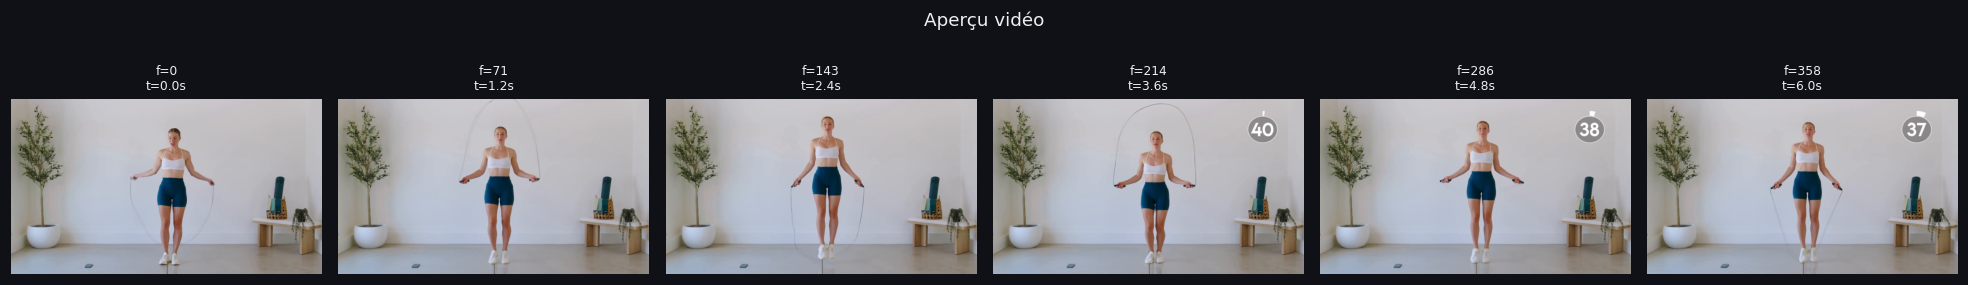

Pics GT (stride-ajusté) : [61, 91, 126, 156, 186, 211, 241, 266, 296, 321, 351]


In [62]:
# STRIDE=2 pour les vidéos lentes afin de réduire le temps de traitement
STRIDE=1 if MEAN_PERIOD<0.8 else 2
RESIZE_W=640
_cap=cv2.VideoCapture(VIDEO_PATH); frames=[]; fi=0
while True:
    ok,frame=_cap.read()
    if not ok: break
    if fi%STRIDE==0:
        h,w=frame.shape[:2]
        frame=cv2.resize(frame,(RESIZE_W,int(h*RESIZE_W/w)))
        frames.append(frame)
    fi+=1
_cap.release()
EFF_FPS=FPS/STRIDE; N=len(frames)
GT_PEAKS_EFF=[p//STRIDE for p in GT_PEAKS]
print(f'{N} frames  stride={STRIDE}  eff_fps={EFF_FPS:.1f}')
fig,axes=plt.subplots(1,6,figsize=(18,3))
for ax,idx in zip(axes,np.linspace(0,N-1,6).astype(int)):
    ax.imshow(cv2.cvtColor(frames[idx],cv2.COLOR_BGR2RGB))
    ax.set_title(f'f={idx*STRIDE}\nt={idx*STRIDE/FPS:.1f}s',fontsize=8)
    ax.axis('off')
plt.suptitle('Aperçu vidéo',color='#ecf0f1'); plt.tight_layout(); plt.show()
print(f'Pics GT (stride-ajusté) : {GT_PEAKS_EFF}')


## Cellule 9 — Définition des méthodes de détection

In [63]:
def _pose(frames, fps, period):
    """
    Suivi de pose MediaPipe Tasks API (mediapipe >= 0.10.x sans solutions).

    motion_energy     -> gradient de position du poignet (pic = vitesse max)
    position_extreme  -> position brute du membre (pic = extreme positionnelle)
    position_crossing -> position brute ; passages directionnels dans smooth_and_detect
    """
    if not _MP: raise RuntimeError('mediapipe non installé')

    import urllib.request, os
    _MODEL = '/content/pose_landmarker_lite.task'
    if not os.path.exists(_MODEL):
        print('  Téléchargement du modèle pose...')
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
            'pose_landmarker_lite/float16/1/pose_landmarker_lite.task',
            _MODEL)

    # Indices landmarks (identiques à l'ancienne API)
    LW, RW = 15, 16   # poignets
    LA, RA = 27, 28   # chevilles
    LS, RS = 11, 12   # épaules

    lm_data = {k: [] for k in ['lw_x','lw_y','rw_x','rw_y',
                                'la_x','la_y','ra_x','ra_y',
                                'ls_x','ls_y','rs_x','rs_y']}

    opts = _mp_vision.PoseLandmarkerOptions(
        base_options=_mp_tasks.BaseOptions(model_asset_path=_MODEL),
        running_mode=_mp_vision.RunningMode.VIDEO,
    )
    with _mp_vision.PoseLandmarker.create_from_options(opts) as lmker:
        for i, f in enumerate(tqdm(frames, desc='Pose')):
            h, w = f.shape[:2]
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                              data=cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            res = lmker.detect_for_video(mp_img, timestamp_ms=int(i * 1000 / fps))
            if res.pose_landmarks:
                lm = res.pose_landmarks[0]
                lm_data['lw_x'].append(lm[LW].x * w); lm_data['lw_y'].append(lm[LW].y * h)
                lm_data['rw_x'].append(lm[RW].x * w); lm_data['rw_y'].append(lm[RW].y * h)
                lm_data['la_x'].append(lm[LA].x * w); lm_data['la_y'].append(lm[LA].y * h)
                lm_data['ra_x'].append(lm[RA].x * w); lm_data['ra_y'].append(lm[RA].y * h)
                lm_data['ls_x'].append(lm[LS].x * w); lm_data['ls_y'].append(lm[LS].y * h)
                lm_data['rs_x'].append(lm[RS].x * w); lm_data['rs_y'].append(lm[RS].y * h)
            else:
                for k in lm_data: lm_data[k].append(np.nan)

    filled = {}; valid_ratios = []
    for k, v in lm_data.items():
        arr, vr = fill_nan(np.array(v, float), 12)
        filled[k] = arr; valid_ratios.append(vr)
    valid = float(np.mean(valid_ratios))

    sem   = SIGNAL_SEMANTICS
    ax    = POSE_AXIS.lower()
    label = EVENT_LABEL.lower()

    if sem == 'motion_energy':
        # Gradient de position = vitesse vraie ; choisir le poignet le plus détecté
        n_l = np.sum(~np.isnan(np.array(lm_data['lw_x'], float)))
        n_r = np.sum(~np.isnan(np.array(lm_data['rw_x'], float)))
        wx = filled['lw_x'] if n_l >= n_r else filled['rw_x']
        wy = filled['lw_y'] if n_l >= n_r else filled['rw_y']
        if ax == 'x':
            raw = np.abs(np.gradient(wx));  aname = 'wrist X velocity'
        elif ax == 'y':
            raw = np.abs(np.gradient(wy));  aname = 'wrist Y velocity'
        else:
            vx = np.gradient(wx); vy = np.gradient(wy)
            raw = np.sqrt(vx**2 + vy**2);  aname = 'wrist speed'
        sig_name = aname

    elif sem in ('position_extreme', 'position_crossing'):
        # Routage vers le landmark approprié selon EVENT_LABEL
        if any(kw in label for kw in ('foot','tap','step','kick')):
            # Cheville Y : sol = grand Y = pic naturel
            la = filled['la_y']; ra = filled['ra_y']
            valid_la = np.nanstd(la) > 5; valid_ra = np.nanstd(ra) > 5
            if valid_la and valid_ra:
                raw = (la + ra) / 2; sig_name = 'mean ankle Y px'
            elif valid_la:
                raw = la; sig_name = 'left ankle Y px'
            else:
                raw = ra; sig_name = 'right ankle Y px'

        elif any(kw in label for kw in ('spin', 'turn', 'rotate')):
            # Largeur d'épaule signée : pic = face caméra
            # abs() piquerait deux fois par tour
            sw = filled['rs_x'] - filled['ls_x']
            raw = sw; sig_name = 'shoulder width signed (rs_x - ls_x) px'
            print("  Spin : largeur d'épaule signée utilisée. "
                  "Si les événements sont des creux, mettre INVERT_SIGNAL=True.")

        else:
            # Par défaut : poignet sur l'axe choisi, plus grande variance
            if ax == 'x':
                lsig = filled['lw_x']; rsig = filled['rw_x']; axis_label = 'X'
            elif ax == 'y':
                lsig = filled['lw_y']; rsig = filled['rw_y']; axis_label = 'Y'
            else:
                lsig = np.sqrt(filled['lw_x']**2 + filled['lw_y']**2)
                rsig = np.sqrt(filled['rw_x']**2 + filled['rw_y']**2)
                axis_label = 'mag'
            if np.nanstd(lsig) >= np.nanstd(rsig):
                raw = lsig; sig_name = f'left wrist {axis_label} px'
            else:
                raw = rsig; sig_name = f'right wrist {axis_label} px'

    else:
        raw = filled['lw_x']; sig_name = 'left wrist X px (fallback)'

    return {'name':'Pose (MediaPipe)', 'key':'pose', 'raw_signal':raw,
            'signal_name':sig_name, 'valid_ratio':valid, 'semantics':sem}
def _sparse_lk(frames, fps, period):
    lk   = dict(winSize=(21,21), maxLevel=3,
                criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 20, 0.01))
    feat = dict(maxCorners=200, qualityLevel=0.01, minDistance=7, blockSize=7)
    pg   = to_gray(frames[0])
    p0   = cv2.goodFeaturesToTrack(pg, mask=None, **feat)

    p0_orig = p0.copy() if p0 is not None else None
    raw  = [0.0]
    signed = (SIGNAL_SEMANTICS == 'position_extreme')
    ax   = SIGNAL_AXIS.lower()

    for f in tqdm(frames[1:], desc='Sparse LK'):
        g = to_gray(f)
        if p0 is None or len(p0) < 10:
            p0 = cv2.goodFeaturesToTrack(pg, mask=None, **feat)
            p0_orig = p0.copy() if p0 is not None else None
        if p0 is not None:
            p1, st, _ = cv2.calcOpticalFlowPyrLK(pg, g, p0, None, **lk)
            if p1 is not None and st is not None:
                gn = p1[st==1]; go = p0[st==1]
                if len(gn):
                    if signed:
                        if ax == 'x':   raw.append(float(np.mean(gn[:,0] - go[:,0])))
                        elif ax == 'y': raw.append(float(np.mean(gn[:,1] - go[:,1])))
                        else:           raw.append(float(np.mean(np.linalg.norm(gn-go, axis=1))))
                    else:
                        raw.append(float(np.mean(np.linalg.norm(gn-go, axis=1))))
                    p0 = gn.reshape(-1,1,2); pg = g; continue
        raw.append(np.nan); pg = g

    r, v = fill_nan(np.array(raw, float), 12)
    sig = ('signed X disp' if signed and ax=='x' else
           'signed Y disp' if signed and ax=='y' else 'displacement mag')
    return {'name':'Sparse LK', 'key':'sparse_lk', 'raw_signal':r,
            'signal_name':sig, 'valid_ratio':v}


def _dense_points_lk(frames, fps, period):
    fh, fw = frames[0].shape[:2]; step = 18
    xs   = np.arange(step//2, fw, step)
    ys   = np.arange(fh//3,   fh, step)
    grid = np.array([(x,y) for y in ys for x in xs], dtype=np.float32).reshape(-1,1,2)
    lk   = dict(winSize=(17,17), maxLevel=2,
                criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 15, 0.01))
    pg   = to_gray(frames[0])
    # Mode signé : déplacement depuis la grille initiale (pas cumulatif)
    signed = (SIGNAL_SEMANTICS == 'position_extreme')
    ax     = SIGNAL_AXIS.lower()
    raw    = [0.0]

    for f in tqdm(frames[1:], desc='Dense Points LK'):
        g = to_gray(f)
        p0 = grid.copy()   # always track from original grid positions
        p1, st, _ = cv2.calcOpticalFlowPyrLK(pg, g, p0, None, **lk)
        if p1 is not None and st is not None:
            gn = p1[st==1]; go = p0[st==1]
            if len(gn):
                if signed:
                    if ax == 'x':   raw.append(float(np.mean(gn[:,0] - go[:,0])))
                    elif ax == 'y': raw.append(float(np.mean(gn[:,1] - go[:,1])))
                    else:           raw.append(float(np.mean(np.linalg.norm(gn-go, axis=1))))
                else:
                    raw.append(float(np.mean(np.linalg.norm(gn-go, axis=1))))
            else:
                raw.append(np.nan)
        else:
            raw.append(np.nan)
        pg = g   # advance reference frame

    r, v = fill_nan(np.array(raw, float), 12)
    sig = ('signed X disp from grid' if signed and ax=='x' else
           'signed Y disp from grid' if signed and ax=='y' else 'grid displacement mag')
    return {'name':'Dense Points LK', 'key':'dense_points_lk', 'raw_signal':r,
            'signal_name':sig, 'valid_ratio':v}


def _dense_flow(frames, fps, period):
    pg  = to_gray(frames[0]); raw = [0.0]
    signed = (SIGNAL_SEMANTICS == 'position_extreme')
    ax     = SIGNAL_AXIS.lower()
    for f in tqdm(frames[1:], desc='Dense Flow'):
        g  = to_gray(f)
        fl = cv2.calcOpticalFlowFarneback(pg, g, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        if signed:
            if ax == 'x':   raw.append(float(np.mean(fl[...,0])))
            elif ax == 'y': raw.append(float(np.mean(fl[...,1])))
            else:           raw.append(float(np.mean(np.sqrt(fl[...,0]**2+fl[...,1]**2))))
        else:
            raw.append(float(np.mean(np.sqrt(fl[...,0]**2+fl[...,1]**2))))
        pg = g
    r, v = fill_nan(np.array(raw, float), 12)
    sig = ('mean signed X flow' if signed and ax=='x' else
           'mean signed Y flow' if signed and ax=='y' else 'mean flow mag')
    return {'name':'Dense Flow', 'key':'dense_flow', 'raw_signal':r,
            'signal_name':sig, 'valid_ratio':v}


def _pixel_diff(frames, fps, period):
    pg = to_gray(frames[0]); raw = [0.0]
    for f in tqdm(frames[1:], desc='Pixel Diff'):
        g = to_gray(f); raw.append(float(np.mean(cv2.absdiff(g, pg)))); pg = g
    r, v = fill_nan(np.array(raw, float), 12)
    return {'name':'Pixel Difference', 'key':'pixel_diff', 'raw_signal':r,
            'signal_name':'mean abs pixel diff', 'valid_ratio':v}


def _raft(frames, fps, period):
    if not _TORCH: raise RuntimeError('PyTorch requis')
    weights = Raft_Small_Weights.DEFAULT
    model   = raft_small(weights=weights).to(DEVICE).eval()
    tf      = weights.transforms(); raw = [0.0]
    signed  = (SIGNAL_SEMANTICS == 'position_extreme')
    ax      = SIGNAL_AXIS.lower()
    def pad8(f):
        h, w = f.shape[:2]
        ph = (8-h%8)%8; pw = (8-w%8)%8
        return cv2.copyMakeBorder(f,0,ph,0,pw,cv2.BORDER_REFLECT) if ph or pw else f
    def ft(f):
        return torch.from_numpy(cv2.cvtColor(pad8(f),cv2.COLOR_BGR2RGB))               .permute(2,0,1).unsqueeze(0).float().to(DEVICE)
    err = 0
    for i in tqdm(range(1,len(frames)), desc='RAFT'):
        try:
            i1, i2 = tf(ft(frames[i-1]), ft(frames[i]))
            with torch.no_grad(): fl = model(i1,i2)[-1][0].cpu().numpy()
            if signed:
                if ax=='x':   raw.append(float(np.mean(fl[0])))
                elif ax=='y': raw.append(float(np.mean(fl[1])))
                else:         raw.append(float(np.mean(np.sqrt(fl[0]**2+fl[1]**2))))
            else:
                raw.append(float(np.mean(np.sqrt(fl[0]**2+fl[1]**2))))
        except Exception as e:
            err += 1
            if err <= 3: print(f'  RAFT frame {i} erreur : {e}')
            raw.append(np.nan)
    if err: print(f'  RAFT : {err}/{len(frames)-1} frames échouées')
    r, v = fill_nan(np.array(raw, float), 12)
    sig = ('deep flow signed X' if signed and ax=='x' else
           'deep flow signed Y' if signed and ax=='y' else 'deep flow mag')
    return {'name':'RAFT', 'key':'raft', 'raw_signal':r,
            'signal_name':sig, 'valid_ratio':v}


def _vit(frames, fps, period):
    if not _TORCH or not _TIMM: raise RuntimeError('PyTorch+timm requis')
    model = timm.create_model('vit_base_patch16_224',pretrained=True,num_classes=0).to(DEVICE).eval()
    tf    = T.Compose([T.ToPILImage(),T.Resize((224,224)),T.ToTensor(),
                       T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    feats = []
    for f in tqdm(frames, desc='ViT'):
        try:
            inp = tf(cv2.cvtColor(f,cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
            with torch.no_grad(): feats.append(model(inp).squeeze().cpu().numpy())
        except: feats.append(None)
    raw = [0.0]
    for i in range(1,len(feats)):
        if feats[i] is None or feats[i-1] is None: raw.append(np.nan); continue
        a, b = feats[i-1], feats[i]
        raw.append(float(1 - np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-8)))
    r, v = fill_nan(np.array(raw, float), 12)
    return {'name':'ViT Features', 'key':'vit', 'raw_signal':r,
            'signal_name':'ViT feature distance', 'valid_ratio':v,
            'semantics':'motion_energy'}


def _midas(frames, fps, period):
    if not _TORCH or not _TIMM: raise RuntimeError('PyTorch+timm requis')
    model = timm.create_model('tf_efficientnet_lite3',pretrained=True,features_only=False).to(DEVICE).eval()
    tf    = T.Compose([T.ToPILImage(),T.Resize((256,256)),T.ToTensor(),
                       T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    prev = None; raw = [0.0]
    for f in tqdm(frames, desc='MiDaS'):
        try:
            inp = tf(cv2.cvtColor(f,cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                d = model(inp)
                depth = (d[-1] if isinstance(d,(list,tuple)) else d).squeeze().cpu().numpy()
            if prev is not None: raw.append(float(np.mean(np.abs(depth-prev))))
            prev = depth
        except: raw.append(np.nan)
    r, v = fill_nan(np.array(raw, float), 12)
    return {'name':'MiDaS Depth', 'key':'midas', 'raw_signal':r,
            'signal_name':'mean abs depth change', 'valid_ratio':v,
            'semantics':'motion_energy'}


def _dtw(frames, fps, period, gt_peaks_eff):
    if not gt_peaks_eff: raise ValueError('DTW nécessite des pics GT')
    pg   = to_gray(frames[0]); base = [0.0]
    signed = (SIGNAL_SEMANTICS == 'position_extreme')
    ax     = SIGNAL_AXIS.lower()
    for f in tqdm(frames[1:], desc='DTW base'):
        g  = to_gray(f)
        fl = cv2.calcOpticalFlowFarneback(pg,g,None,0.5,3,15,3,5,1.2,0)
        if signed and ax=='x':   base.append(float(np.mean(fl[...,0])))
        elif signed and ax=='y': base.append(float(np.mean(fl[...,1])))
        else:                    base.append(float(np.mean(np.sqrt(fl[...,0]**2+fl[...,1]**2))))
        pg = g
    bs, _ = fill_nan(np.array(base, float), 12)
    bs     = savgol_smooth(bs, SG_WINDOW, 2)
    # Deuxième pic GT comme ancre (plus stable que le premier)
    ref_idx = gt_peaks_eff[1] if len(gt_peaks_eff) > 1 else gt_peaks_eff[0]
    hw      = max(4, int(period*fps*0.5))
    tmpl    = bs[max(0,ref_idx-hw):min(len(bs),ref_idx+hw)]
    if len(tmpl) < 4: raise ValueError('Template trop court')
    tw     = len(tmpl); scores = np.zeros(len(bs))
    for s in range(len(bs)-tw+1):
        win = bs[s:s+tw]
        d   = cdist(tmpl.reshape(-1,1), win.reshape(-1,1))
        dp  = np.full((len(tmpl),tw), np.inf); dp[0,0] = d[0,0]
        for i in range(1,len(tmpl)): dp[i,0] = dp[i-1,0]+d[i,0]
        for j in range(1,tw):        dp[0,j] = dp[0,j-1]+d[0,j]
        for i in range(1,len(tmpl)):
            for j in range(1,tw):
                dp[i,j] = d[i,j]+min(dp[i-1,j],dp[i,j-1],dp[i-1,j-1])
        mid = s+tw//2
        if mid < len(scores): scores[mid] = -dp[-1,-1]
    rng  = scores.max()-scores.min()
    norm = (scores-scores.min())/rng if rng>0 else np.zeros_like(scores)
    return {'name':'DTW', 'key':'dtw', 'raw_signal':norm,
            'signal_name':'DTW similarity', 'valid_ratio':1.0}


ALL_METHODS = {
    'pose':_pose, 'sparse_lk':_sparse_lk, 'dense_points_lk':_dense_points_lk,
    'dense_flow':_dense_flow, 'pixel_diff':_pixel_diff,
    'raft':_raft, 'vit':_vit, 'midas':_midas, 'dtw':_dtw,
}
print(f'{len(ALL_METHODS)} méthodes définies  |  semantics={SIGNAL_SEMANTICS}')


9 méthodes définies  |  semantics=position_extreme


## Cellule 10 — Exécution des méthodes
Commenter les méthodes à exclure.

Region 'lower'  |  semantics=position_extreme  axis=y  invert=False
  AVERTISSEMENT : vit ignoré — motion_energy uniquement (SIGNAL_SEMANTICS='position_extreme'). Mettre FORCE_ALL_METHODS=True pour l'inclure.
  AVERTISSEMENT : midas ignoré — motion_energy uniquement (SIGNAL_SEMANTICS='position_extreme'). Mettre FORCE_ALL_METHODS=True pour l'inclure.
Exécution de 7 méthodes  (ignorées : ['vit', 'midas'])
Méthode : pose


Pose:   0%|          | 0/359 [00:00<?, ?it/s]

  11 événements  (11.2s)


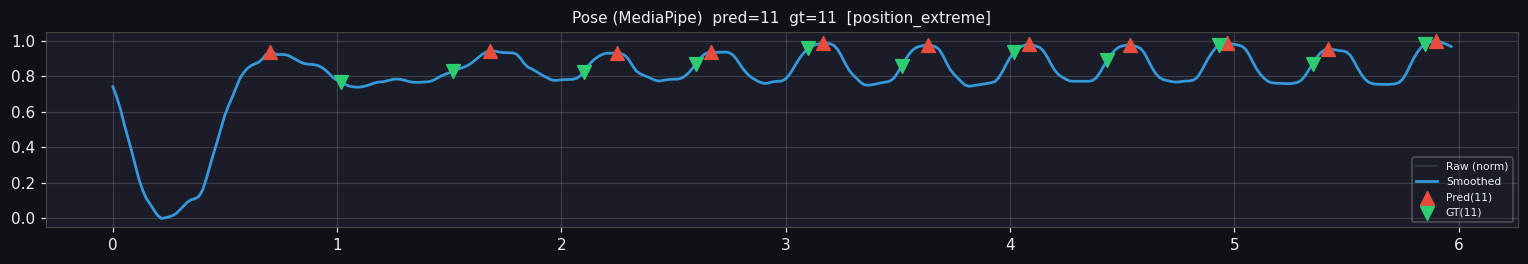

Méthode : sparse_lk


Sparse LK:   0%|          | 0/358 [00:00<?, ?it/s]

  12 événements  (1.4s)


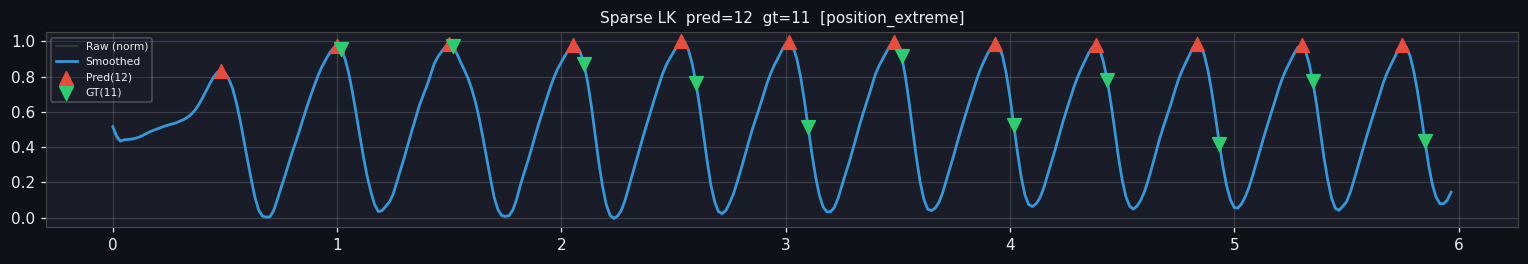

Méthode : dense_points_lk


Dense Points LK:   0%|          | 0/358 [00:00<?, ?it/s]

  12 événements  (1.3s)


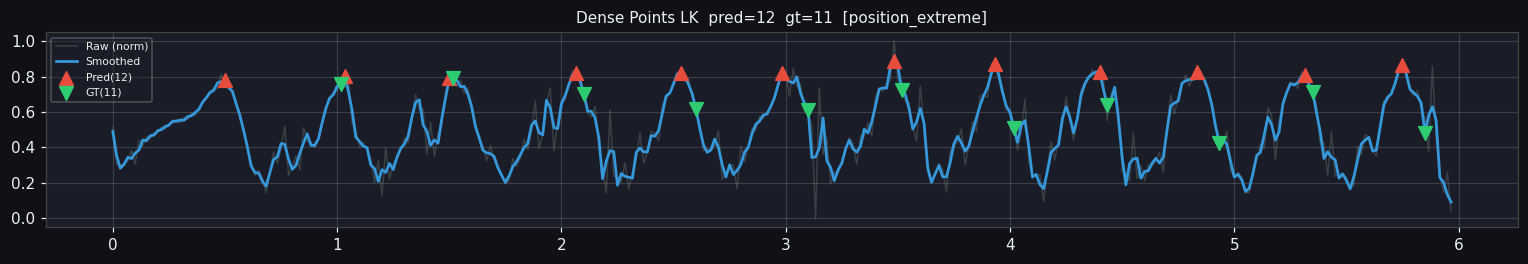

Méthode : dense_flow


Dense Flow:   0%|          | 0/358 [00:00<?, ?it/s]

  12 événements  (51.5s)


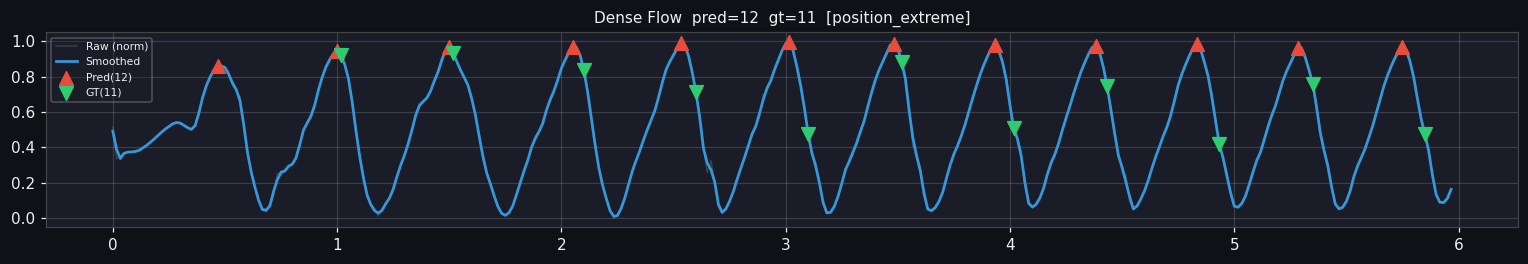

Méthode : pixel_diff


Pixel Diff:   0%|          | 0/358 [00:00<?, ?it/s]

  13 événements  (0.3s)


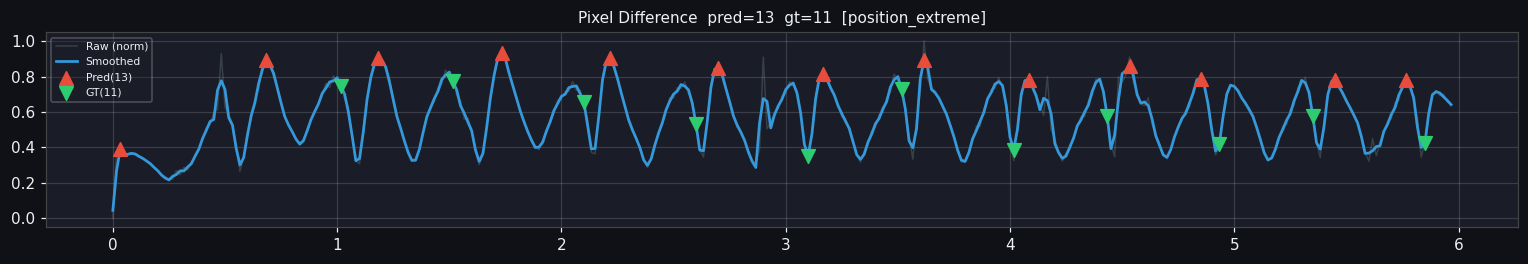

Méthode : raft


RAFT:   0%|          | 0/358 [00:00<?, ?it/s]

  14 événements  (19.2s)


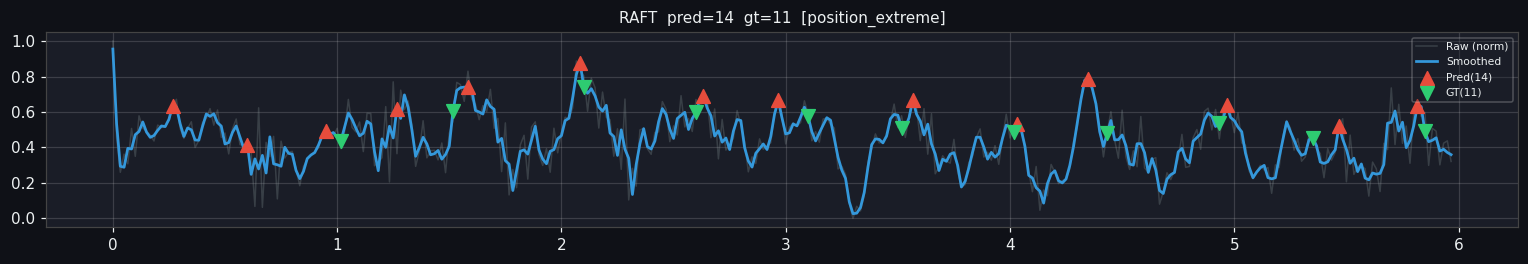

Méthode : dtw


DTW base:   0%|          | 0/358 [00:00<?, ?it/s]

  11 événements  (33.8s)


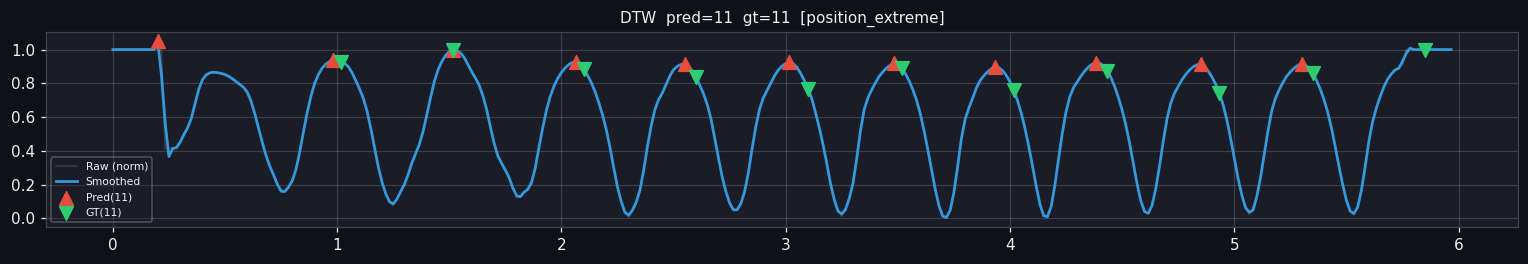

Terminé : 7/7 méthodes


In [64]:
METHODS_TO_RUN=[
    'pose',             # ~30s
    'sparse_lk',        # ~5s
    'dense_points_lk',  # ~10s
    'dense_flow',       # ~8s
    'pixel_diff',       # ~3s
    'raft',             # ~2min GPU
    'vit',              # ~3min GPU
    'midas',            # ~4min GPU
    'dtw',              # ~30s
]

# ViT et MiDaS ne peuvent pas encoder la position — motion_energy uniquement
_MOTION_ENERGY_ONLY = {'vit', 'midas'}

# Surcharge de prominence par méthode (après normalisation 0-1)
_PROM_OVERRIDES = {
    'raft':  0.03,
    'vit':   0.03,
    'midas': 0.03,
    'pose':  POSE_PROM_FACTOR,
}


region_frames = [apply_region(f) for f in frames]
print(f"Region '{REGION}'  |  semantics={SIGNAL_SEMANTICS}  axis={SIGNAL_AXIS}  invert={INVERT_SIGNAL}")

results = {}; runtimes = {}
active  = {k:ALL_METHODS[k] for k in METHODS_TO_RUN if k in ALL_METHODS}


skipped = []
if SIGNAL_SEMANTICS != 'motion_energy' and not FORCE_ALL_METHODS:
    for k in list(active.keys()):
        if k in _MOTION_ENERGY_ONLY:
            print(f'  AVERTISSEMENT : {k} ignoré — motion_energy uniquement '
                  f'(SIGNAL_SEMANTICS={SIGNAL_SEMANTICS!r}). '
                  f'Mettre FORCE_ALL_METHODS=True pour l\'inclure.')
            skipped.append(k); del active[k]

print(f'Exécution de {len(active)} méthodes  (ignorées : {skipped or "aucune"})')

for key, fn in active.items():
    print(f'{"="*50}')
    print(f'Méthode : {key}')
    t0 = time.time()
    try:
        if key == 'dtw':
            result = fn(region_frames, EFF_FPS, MEAN_PERIOD, GT_PEAKS_EFF)
        else:
            result = fn(region_frames, EFF_FPS, MEAN_PERIOD)


        pf  = _PROM_OVERRIDES.get(key, PROMINENCE_FACTOR)
        md_ = POSE_MIN_DIST_SEC if key == 'pose' else PEAK_MIN_DIST_SEC
        result = smooth_and_detect(result, EFF_FPS, md_, pf, SG_WINDOW, MA_WINDOW)


        if ENABLE_PHASE_FILTER and SIGNAL_SEMANTICS=='motion_energy' and key not in ('pose','dtw'):
            before = len(result['peaks'])
            result['peaks'] = phase_filter(result['peaks'], GT_PEAKS_EFF, EFF_FPS, MEAN_PERIOD)
            result['event_count'] = len(result['peaks'])
            if before != result['event_count']:
                print(f'  Filtre de phase : {before}->{result["event_count"]}')

        runtimes[key] = time.time()-t0
        results[key]  = result
        print(f'  {result["event_count"]} événements  ({runtimes[key]:.1f}s)')


        sg  = result.get('smoothed_sg', result['raw_signal'])
        raw = result['raw_signal']; t_ax = np.arange(len(sg))/EFF_FPS
        fig, ax = plt.subplots(figsize=(14,2.5))
        ax.plot(t_ax, raw, alpha=0.25, color='#95a5a6', lw=1, label='Raw (norm)')
        ax.plot(t_ax, sg,  color='#3498db', lw=1.8, label='Smoothed')
        pk  = result['peaks']; vgt = [g for g in GT_PEAKS_EFF if g<len(sg)]
        if len(pk): ax.scatter(pk/EFF_FPS, sg[pk], color='#e74c3c', s=80, zorder=5,
                               marker='^', label=f'Pred({len(pk)})')
        if vgt:     ax.scatter(np.array(vgt)/EFF_FPS, sg[vgt], color='#2ecc71', s=80,
                               zorder=5, marker='v', label=f'GT({len(GT_PEAKS_EFF)})')
        sem_tag = result.get('semantics', SIGNAL_SEMANTICS)
        ax.set_title(f"{result['name']}  pred={result['event_count']}  gt={len(GT_PEAKS_EFF)}  [{sem_tag}]",
                     color='#ecf0f1', fontsize=10)
        ax.legend(fontsize=7, framealpha=0.3, labelcolor='#ecf0f1', facecolor='#1a1d27')
        ax.grid(alpha=0.15, color='white'); ax.tick_params(colors='#ecf0f1'); ax.spines[:].set_color('#444')
        plt.tight_layout(); plt.show()

    except Exception as e:
        import traceback; print(f'  ERREUR : {e}'); traceback.print_exc()

print(f'Terminé : {len(results)}/{len(active)} méthodes')


## Cellule 11 — Évaluation

In [65]:
def match_events(pred,gt,tol):
    pred,gt=sorted(pred),sorted(gt)
    used_p,used_g,matches=set(),set(),[]
    for pi,p in enumerate(pred):
        best_d,best_gi=tol+1,-1
        for gi,g in enumerate(gt):
            if gi in used_g: continue
            d=abs(p-g)
            if d<=tol and d<best_d: best_d,best_gi=d,gi
        if best_gi>=0:
            matches.append((p,gt[best_gi],p-gt[best_gi]))
            used_p.add(pi); used_g.add(best_gi)
    fp=[pred[i] for i in range(len(pred)) if i not in used_p]
    fn=[gt[i]   for i in range(len(gt))   if i not in used_g]
    return matches,fp,fn

def evaluate(pred,gt,key,name,tol,fps):
    matches,fp_l,fn_l=match_events(pred,gt,tol)
    tp=len(matches); fp=len(fp_l); fn=len(fn_l)
    pr=tp/(tp+fp) if tp+fp else 0; re=tp/(tp+fn) if tp+fn else 0
    f1=2*pr*re/(pr+re) if pr+re else 0
    te=[abs(m[2]) for m in matches]
    return {'key':key,'method':name,'gt_count':len(gt),'pred_count':len(pred),
            'tp':tp,'fp':fp,'fn':fn,'precision':round(pr,4),'recall':round(re,4),'f1':round(f1,4),
            'count_error':len(pred)-len(gt),
            'mean_timing_err_frames':round(float(np.mean(te)),2) if te else None,
            'mean_timing_err_sec':round(float(np.mean(te))/fps,3) if te else None,
            'tolerance_frames':tol,'fp_frames':fp_l,'fn_frames':fn_l,'matches':matches}

def compute_roc_auc(sg,gt_peaks,n_frames,tol):
    labels=np.zeros(n_frames,dtype=int)
    for g in gt_peaks: labels[max(0,g-tol):min(n_frames,g+tol+1)]=1
    sig=np.array(sg,float)[:n_frames]
    if len(sig)<n_frames: sig=np.pad(sig,(0,n_frames-len(sig)),constant_values=sig[-1])
    rng=sig.max()-sig.min()
    score=(sig-sig.min())/rng if rng>0 else np.zeros(n_frames)
    if not _SKLEARN: return {'auc':None,'fpr':None,'tpr':None}
    try:
        auc=float(roc_auc_score(labels,score))
        fpr,tpr,_=roc_curve(labels,score)
        return {'auc':round(auc,4),'fpr':fpr,'tpr':tpr}
    except: return {'auc':None,'fpr':None,'tpr':None}

eval_rows=[]; roc_data={}
for key,res in results.items():
    pred=res['peaks'].tolist() if hasattr(res['peaks'],'tolist') else list(res['peaks'])
    ev=evaluate(pred,GT_PEAKS_EFF,key=key,name=res.get('name',key),
                tol=TOLERANCE_FRAMES,fps=EFF_FPS)
    ev['runtime_sec']=runtimes.get(key)
    sg=res.get('smoothed_sg',res['raw_signal'])
    roc=compute_roc_auc(sg,GT_PEAKS_EFF,N,TOLERANCE_FRAMES)
    ev['roc_auc']=roc['auc']; roc_data[res.get('name',key)]=roc
    eval_rows.append(ev)

cols=['method','precision','recall','f1','roc_auc','count_error',
      'mean_timing_err_sec','tp','fp','fn','runtime_sec']
summary_df=pd.DataFrame([{c:r.get(c) for c in cols} for r in eval_rows])
summary_df=summary_df.sort_values('f1',ascending=False).reset_index(drop=True)
summary_df.to_csv('/content/evaluation_summary.csv',index=False)
print(f'Tolérance : +-{TOLERANCE_FRAMES} frames  période : {MEAN_PERIOD:.3f}s')
display(summary_df.style
    .background_gradient(subset=['f1','precision','recall'],cmap='RdYlGn')
    .background_gradient(subset=['count_error'],cmap='RdYlGn_r')
    .format({'precision':'{:.3f}','recall':'{:.3f}','f1':'{:.3f}',
             'roc_auc':lambda x:f'{x:.3f}' if x else 'N/A',
             'runtime_sec':lambda x:f'{x:.1f}s' if x else '-'}))


Tolérance : +-7 frames  période : 0.483s


,method,precision,recall,f1,roc_auc,count_error,mean_timing_err_sec,tp,fp,fn,runtime_sec
0,Sparse LK,0.917,1.000,0.957,0.673,1,0.059000,11,1,0,1.4s
1,Dense Points LK,0.917,1.000,0.957,0.715,1,0.058000,11,1,0,1.3s
2,Dense Flow,0.917,1.000,0.957,0.671,1,0.061000,11,1,0,51.5s
3,DTW,0.909,0.909,0.909,0.787,0,0.050000,10,1,1,33.8s
4,RAFT,0.714,0.909,0.800,0.747,3,0.052000,10,4,1,19.2s
5,Pixel Difference,0.692,0.818,0.750,0.748,2,0.091000,9,4,2,0.3s
6,Pose (MediaPipe),0.727,0.727,0.727,0.708,0,0.071000,8,3,3,11.2s


## Cellule 12 — Tracés des signaux

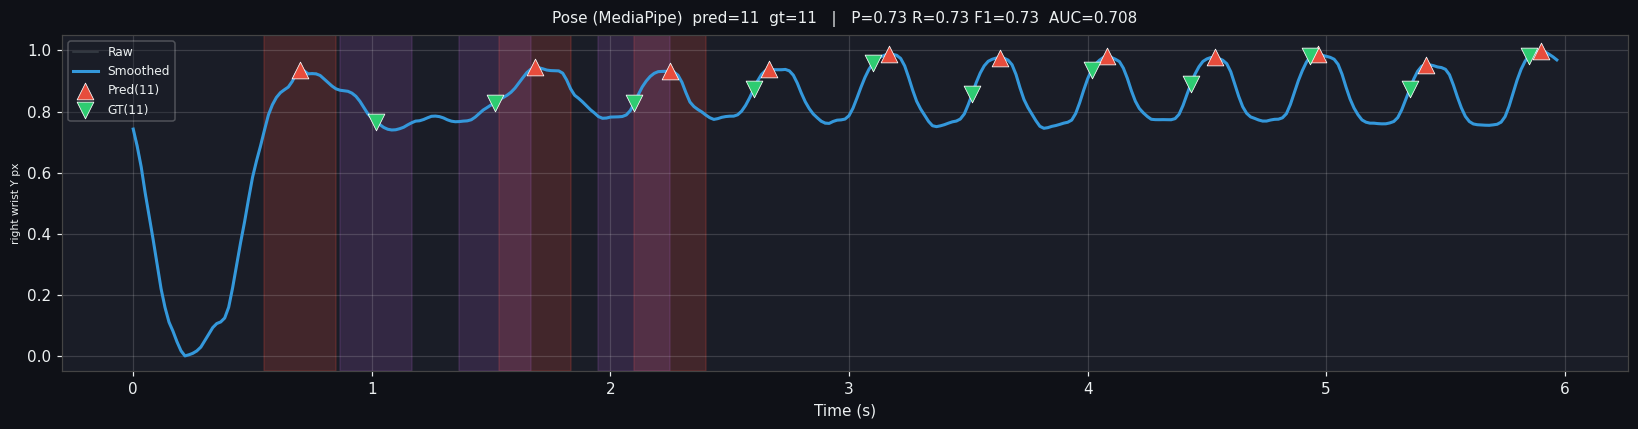

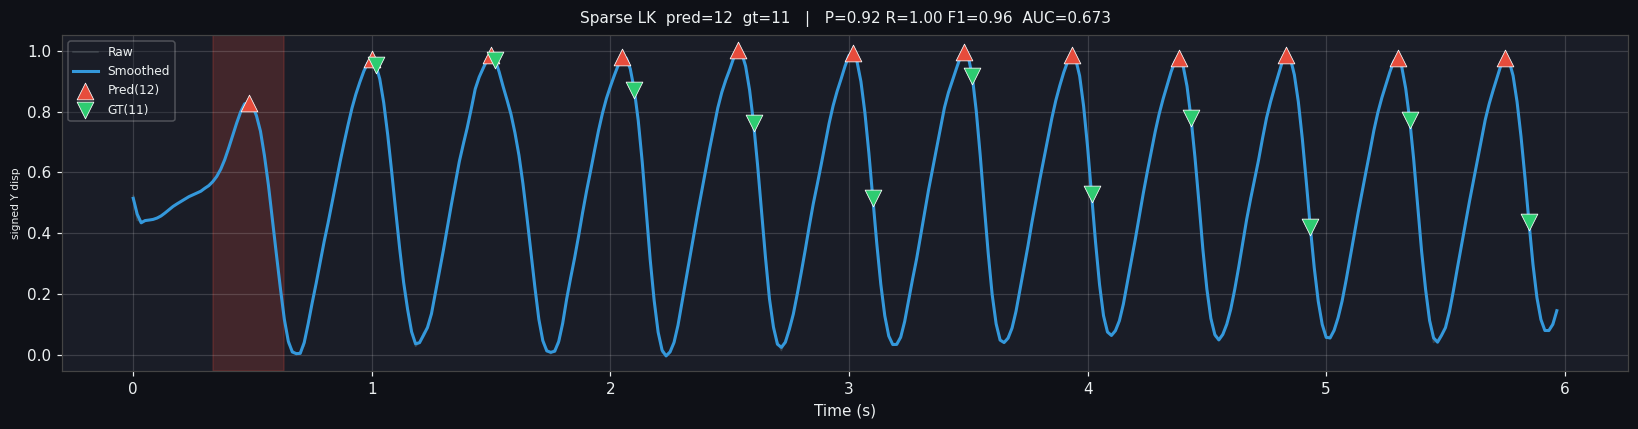

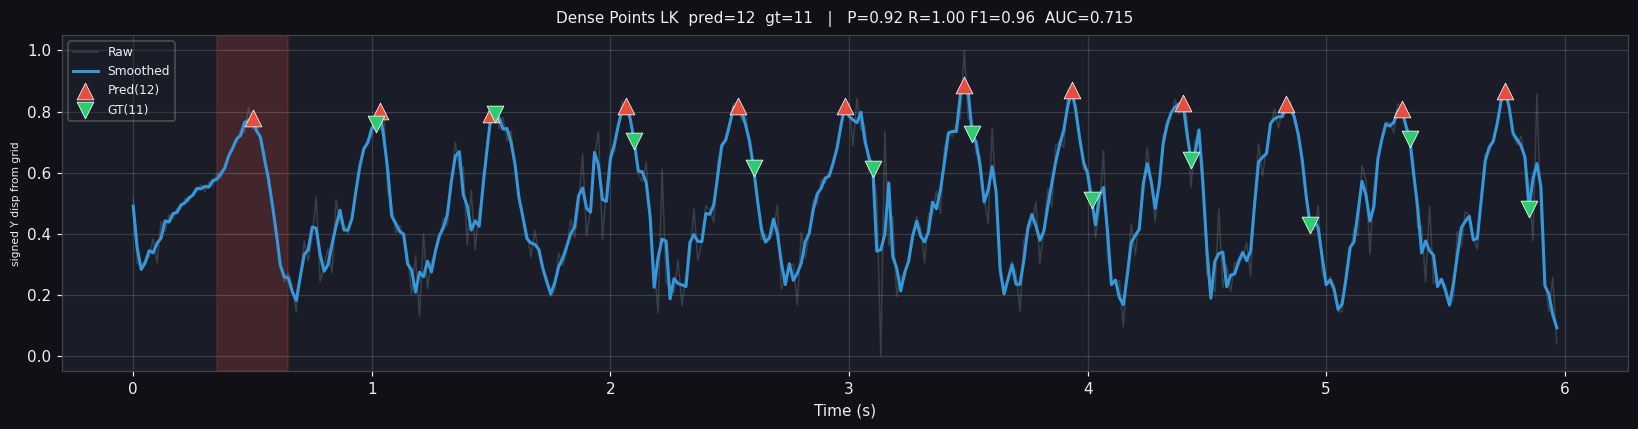

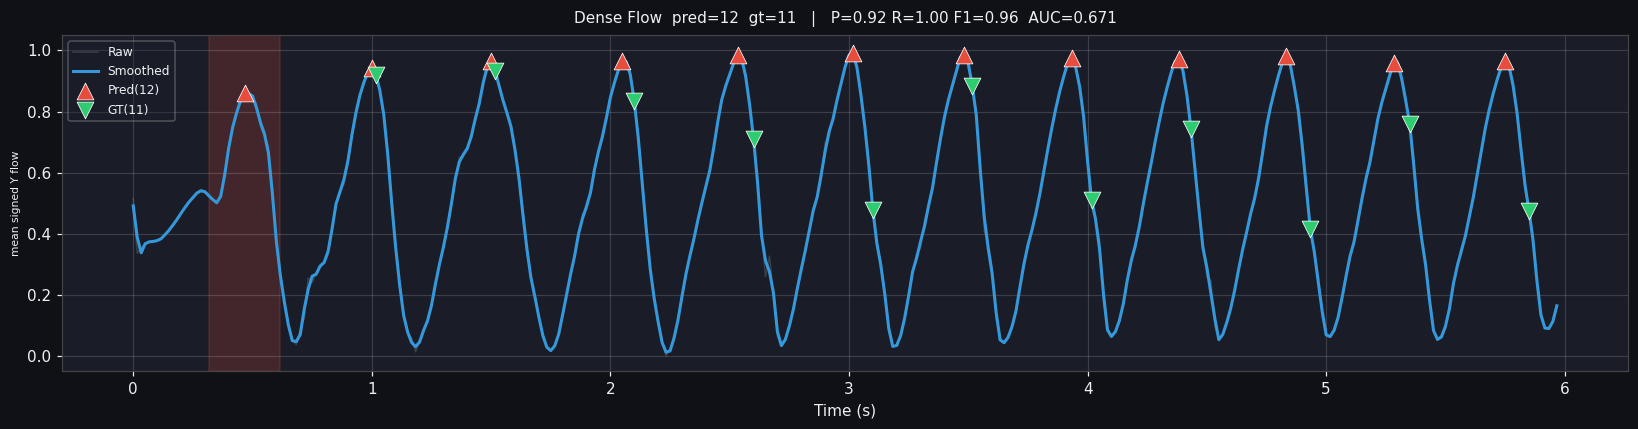

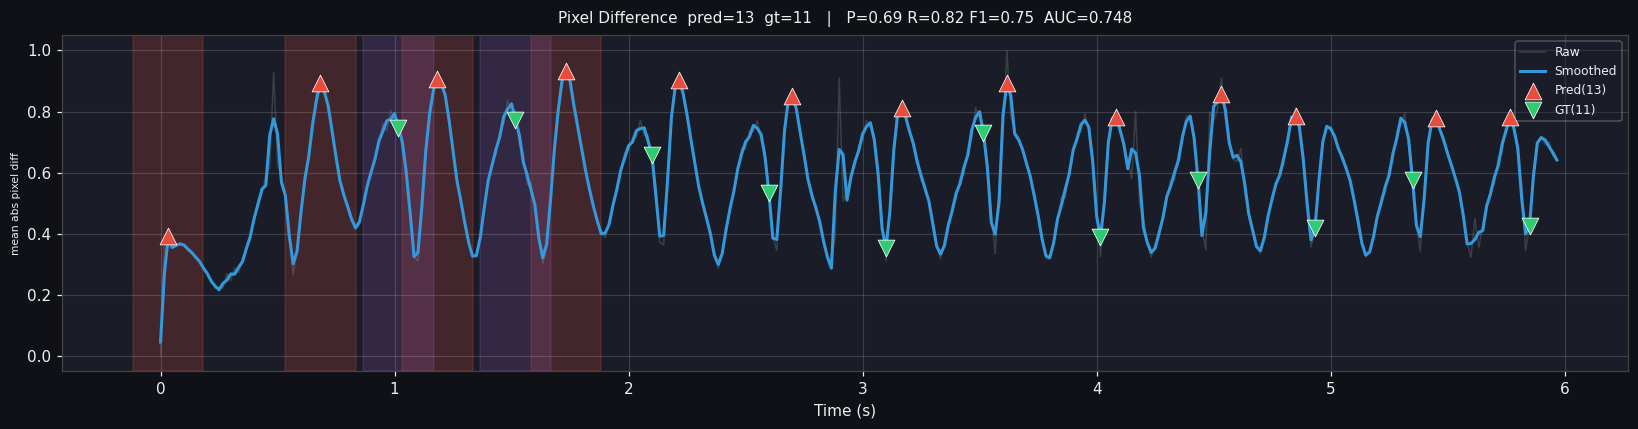

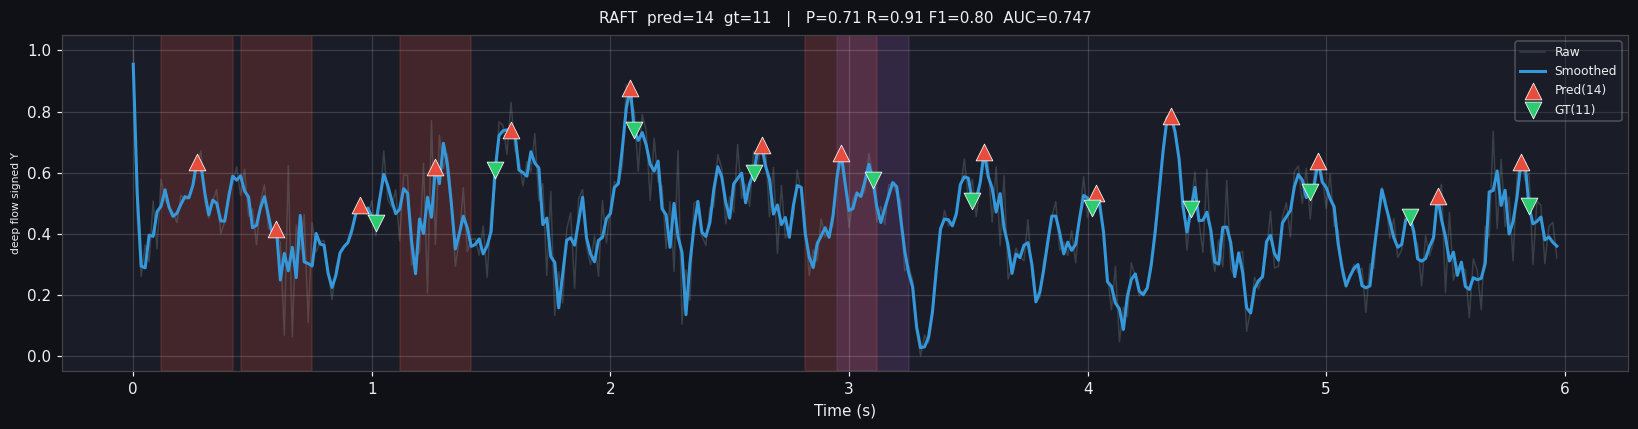

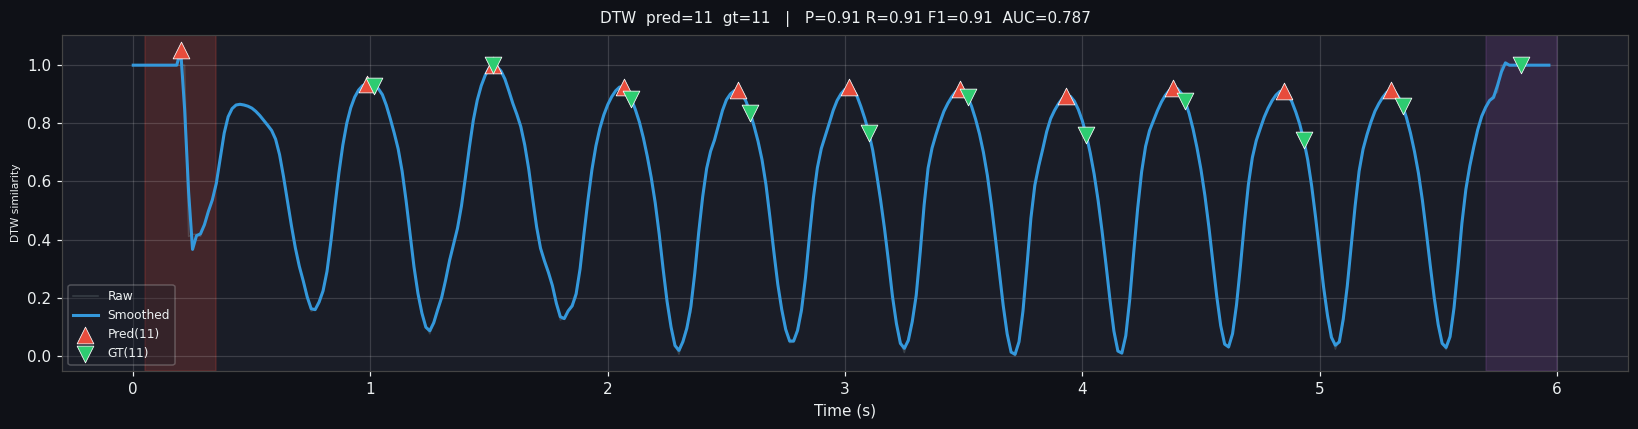

In [66]:
ev_map={r['key']:r for r in eval_rows}
for key,res in results.items():
    ev=ev_map.get(key)
    sg=res.get('smoothed_sg',res['raw_signal']); raw=res['raw_signal']
    pk=res.get('peaks',np.array([])); n=len(raw); t_ax=np.arange(n)/EFF_FPS
    fig,ax=plt.subplots(figsize=(15,4))
    fig.patch.set_facecolor('#0f1117'); ax.set_facecolor('#1a1d27')
    ax.plot(t_ax,raw,alpha=0.25,color='#95a5a6',lw=1,label='Raw')
    ax.plot(t_ax,sg,color='#3498db',lw=2,label='Smoothed')
    if len(pk):
        vp=pk[pk<n]
        ax.scatter(vp/EFF_FPS,sg[vp],color='#e74c3c',s=120,zorder=6,
                   marker='^',label=f'Pred({len(pk)})',edgecolors='white',lw=0.5)
    vgt=[g for g in GT_PEAKS_EFF if g<n]
    if vgt:
        ax.scatter(np.array(vgt)/EFF_FPS,sg[vgt],color='#2ecc71',s=120,zorder=6,
                   marker='v',label=f'GT({len(GT_PEAKS_EFF)})',edgecolors='white',lw=0.5)
    if ev:
        for f in ev['fp_frames']:
            if f<n: ax.axvspan(f/EFF_FPS-.15,f/EFF_FPS+.15,color='#e74c3c',alpha=0.2)
        for f in ev['fn_frames']:
            if f<n: ax.axvspan(f/EFF_FPS-.15,f/EFF_FPS+.15,color='#9b59b6',alpha=0.2)
    title=f"{res['name']}  pred={res.get('event_count','?')}  gt={len(GT_PEAKS_EFF)}"
    if ev:
        auc=f"  AUC={ev['roc_auc']:.3f}" if ev.get('roc_auc') else ''
        title+=f"   |   P={ev['precision']:.2f} R={ev['recall']:.2f} F1={ev['f1']:.2f}{auc}"
    ax.set_title(title,color='#ecf0f1',fontsize=10,pad=8)
    ax.set_xlabel('Time (s)',color='#ecf0f1')
    ax.set_ylabel(res.get('signal_name','signal'),color='#ecf0f1',fontsize=7)
    ax.legend(fontsize=8,framealpha=0.3,labelcolor='#ecf0f1',facecolor='#1a1d27')
    ax.tick_params(colors='#ecf0f1'); ax.spines[:].set_color('#444')
    ax.grid(alpha=0.15,color='white')
    plt.tight_layout()
    plt.savefig(f'/content/{key}_signal.png',dpi=110,bbox_inches='tight',facecolor=fig.get_facecolor())
    plt.show()


## Cellule 13 — Tableau de bord

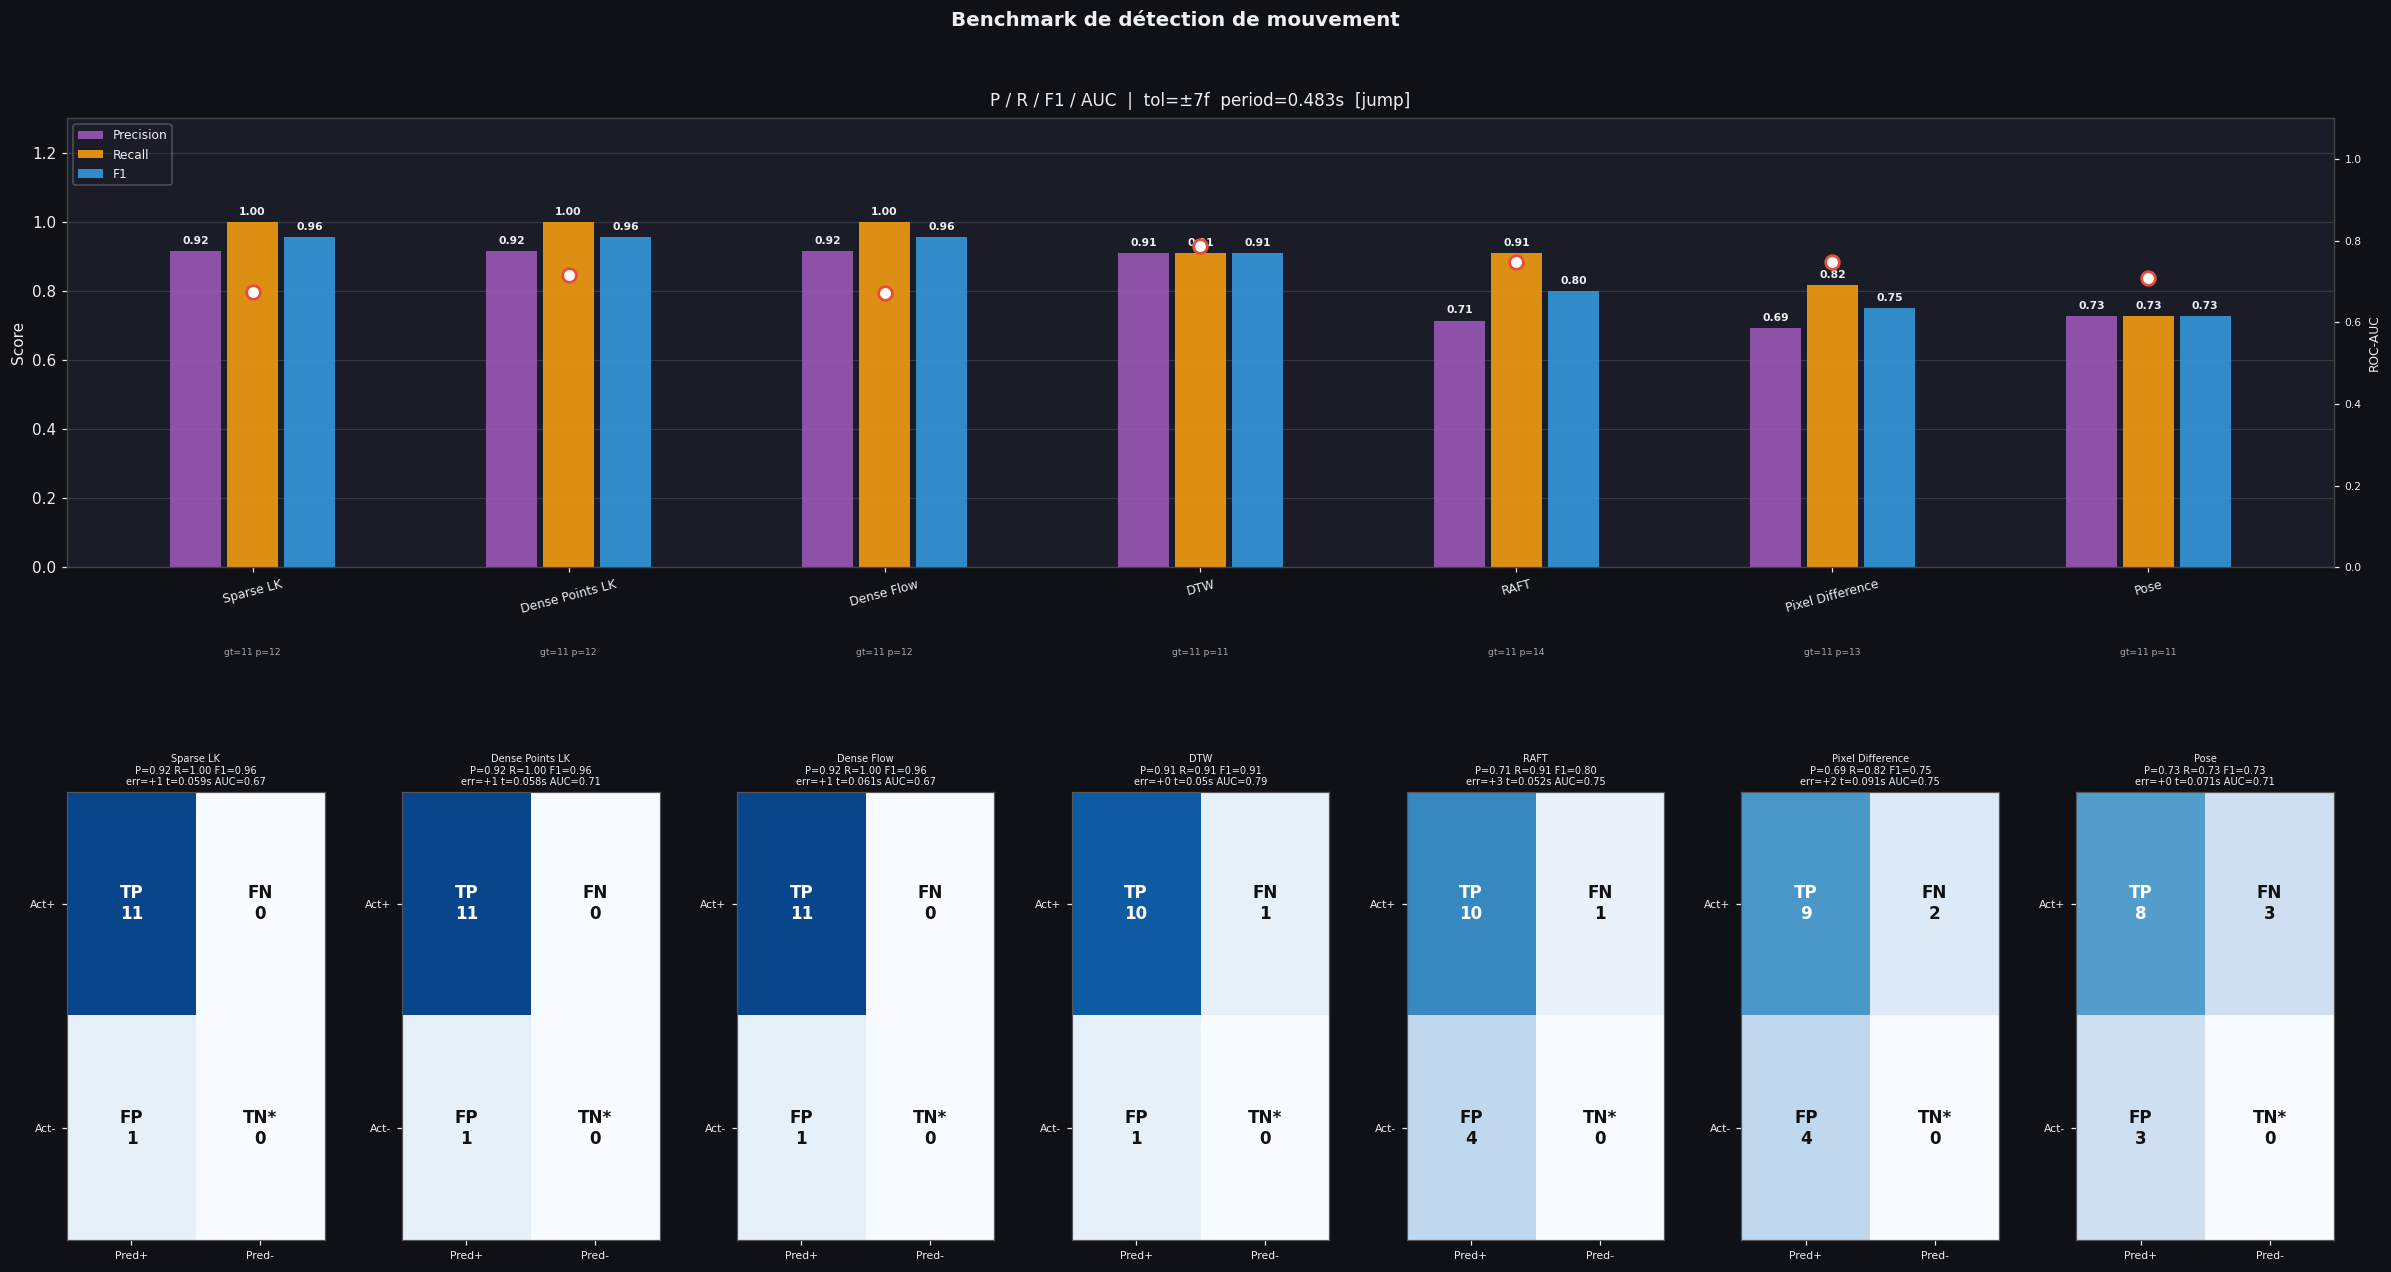

Sauvegardé : /content/dashboard.png


In [67]:
# Trier par F1 décroissant
_rows = sorted(eval_rows, key=lambda r: r['f1'], reverse=True)
n = len(_rows)

if n == 0:
    print("Aucun résultat à afficher");
else:
    _shorts = [r['method'].replace('(MediaPipe)','').replace('(Farneback)','').strip() for r in _rows]
    C = {'bg':'#0f1117','panel':'#1a1d27','text':'#ecf0f1','grid':'#444'}

    if n == 1:

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.patch.set_facecolor(C['bg'])
        ev = _rows[0]
        # Bar chart
        ax = axes[0]; ax.set_facecolor(C['panel'])
        metrics = ['precision','recall','f1']
        vals    = [ev[m] for m in metrics]
        colors  = ['#9b59b6','#f39c12','#3498db']
        bars = ax.bar(metrics, vals, color=colors, alpha=0.9)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}',
                    ha='center', fontsize=11, color=C['text'], fontweight='bold')
        ax.set_ylim(0,1.3); ax.set_title(_shorts[0], color=C['text'], fontsize=12)
        ax.tick_params(colors=C['text']); ax.spines[:].set_color(C['grid'])
        # Confusion matrix
        ax2 = axes[1]; ax2.set_facecolor(C['panel'])
        tp,fp,fn = ev['tp'],ev['fp'],ev['fn']
        mat = np.array([[tp,fn],[fp,0]],dtype=float)
        vmax = max(float(tp+fp+fn),1)
        ax2.imshow(mat,cmap='Blues',vmin=0,vmax=vmax,aspect='auto')
        for ri in range(2):
            for cj in range(2):
                v=int(mat[ri,cj]); tc='white' if mat[ri,cj]>vmax*0.4 else '#111'
                ax2.text(cj,ri,f"{[['TP','FN'],['FP','TN*']][ri][cj]}\n{v}",
                        ha='center',va='center',fontsize=14,fontweight='bold',color=tc)
        ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
        ax2.set_xticklabels(['Pred+','Pred-'],color=C['text'])
        ax2.set_yticklabels(['Act+','Act-'],color=C['text'])
        ax2.tick_params(colors=C['text']); ax2.spines[:].set_color('#555')
        plt.tight_layout()
    else:
        fig = plt.figure(figsize=(max(16, n*3.2), 12))
        fig.patch.set_facecolor(C['bg'])
        gs  = gridspec.GridSpec(2, n, hspace=0.5, wspace=0.3,
                                top=0.90, bottom=0.05, left=0.05, right=0.97)

        # Graphique de métriques (ligne du haut)
        ax_b = fig.add_subplot(gs[0, :]); ax_b.set_facecolor(C['panel'])
        x = np.arange(n); bw = 0.18
        for vals, col, lbl, off in [
            ([r['precision'] for r in _rows], '#9b59b6', 'Precision', -bw),
            ([r['recall']    for r in _rows], '#f39c12', 'Recall',     0),
            ([r['f1']        for r in _rows], '#3498db', 'F1',        +bw),
        ]:
            bars = ax_b.bar(x+off, vals, bw*0.9, label=lbl, color=col, alpha=0.9, zorder=3)
            for bar, v in zip(bars, vals):
                ax_b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                          f'{v:.2f}', ha='center', va='bottom',
                          fontsize=7, color=C['text'], fontweight='bold')

        aucs = [r.get('roc_auc') or 0 for r in _rows]
        ax2  = ax_b.twinx()
        ax2.scatter(x, aucs, color='white', s=80, edgecolors='#e74c3c', lw=1.8, zorder=6, label='AUC')
        ax2.set_ylabel('ROC-AUC', color=C['text'], fontsize=8)
        ax2.set_ylim(0, 1.1); ax2.tick_params(colors=C['text'], labelsize=7)
        ax2.spines[:].set_color(C['grid'])

        ax_b.set_xticks(x)
        ax_b.set_xticklabels(_shorts, color=C['text'], fontsize=8, rotation=15)
        ax_b.set_ylim(0, 1.3); ax_b.set_ylabel('Score', color=C['text'])
        ax_b.set_title(
            f'P / R / F1 / AUC  |  tol=±{TOLERANCE_FRAMES}f  '
            f'period={MEAN_PERIOD:.3f}s  [{EVENT_LABEL}]',
            color=C['text'], fontsize=11, pad=8)
        ax_b.legend(loc='upper left', fontsize=8, framealpha=0.3,
                    labelcolor=C['text'], facecolor=C['panel'])
        ax_b.tick_params(colors=C['text'])
        ax_b.grid(axis='y', alpha=0.12, color='white')
        ax_b.spines[:].set_color(C['grid'])
        for xi, row in zip(x, _rows):
            ax_b.text(xi, -0.18, f"gt={row['gt_count']} p={row['pred_count']}",
                      ha='center', va='top', fontsize=6, color='#aaa',
                      transform=ax_b.get_xaxis_transform())

        # Matrices de confusion (ligne du bas)
        for ci, (ev, short) in enumerate(zip(_rows, _shorts)):
            ax = fig.add_subplot(gs[1, ci]); ax.set_facecolor(C['panel'])
            tp, fp, fn = ev['tp'], ev['fp'], ev['fn']
            mat  = np.array([[tp,fn],[fp,0]], dtype=float)
            vmax = max(float(tp+fp+fn), 1)
            ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax, aspect='auto')
            for ri in range(2):
                for cj in range(2):
                    v  = int(mat[ri,cj])
                    tc = 'white' if mat[ri,cj] > vmax*0.4 else '#111'
                    ax.text(cj, ri, f"{[['TP','FN'],['FP','TN*']][ri][cj]}\n{v}",
                            ha='center', va='center', fontsize=11,
                            fontweight='bold', color=tc)
            ax.set_xticks([0,1]); ax.set_yticks([0,1])
            ax.set_xticklabels(['Pred+','Pred-'], fontsize=7, color=C['text'])
            ax.set_yticklabels(['Act+','Act-'],   fontsize=7, color=C['text'])
            ax.tick_params(colors=C['text']); ax.spines[:].set_color('#555')
            te  = ev['mean_timing_err_sec']
            auc = ev.get('roc_auc')
            ax.set_title(
                f"{short}\nP={ev['precision']:.2f} R={ev['recall']:.2f} F1={ev['f1']:.2f}\n"
                f"err={ev['count_error']:+d} t={te}s" + (f" AUC={auc:.2f}" if auc else ''),
                fontsize=6.5, color=C['text'], pad=4)

    fig.text(0.5, 0.97, 'Benchmark de détection de mouvement',
             ha='center', fontsize=13, color=C['text'], fontweight='bold')
    plt.savefig('/content/dashboard.png', dpi=110, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('Sauvegardé : /content/dashboard.png')


## Cellule 14 — Courbes ROC

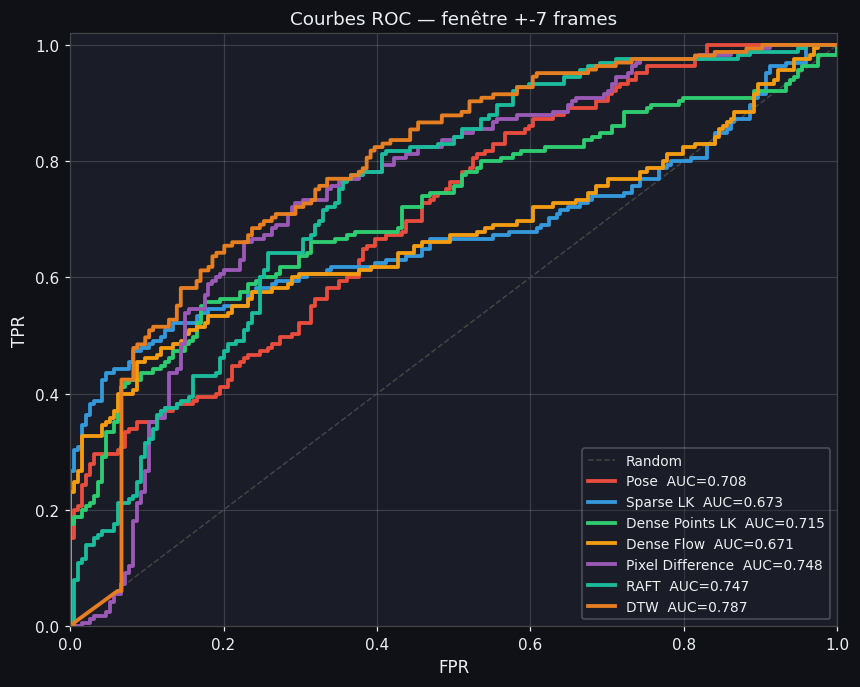

In [68]:
_colors=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#fd79a8','#a29bfe','#ffeaa7']
fig,ax=plt.subplots(figsize=(9,7))
fig.patch.set_facecolor('#0f1117'); ax.set_facecolor('#1a1d27')
ax.plot([0,1],[0,1],'--',color='#444',lw=1,label='Random')
for (name,data),col in zip(roc_data.items(),_colors):
    if data['fpr'] is None: continue
    ax.plot(data['fpr'],data['tpr'],color=col,lw=2.5,
            label=f"{name.replace('(MediaPipe)','').strip()}  AUC={data['auc']:.3f}")
ax.set_xlabel('FPR',color='#ecf0f1',fontsize=11)
ax.set_ylabel('TPR',color='#ecf0f1',fontsize=11)
ax.set_title(f'Courbes ROC — fenêtre +-{TOLERANCE_FRAMES} frames',color='#ecf0f1',fontsize=12)
ax.legend(fontsize=9,framealpha=0.3,labelcolor='#ecf0f1',facecolor='#1a1d27',loc='lower right')
ax.tick_params(colors='#ecf0f1'); ax.spines[:].set_color('#444')
ax.grid(alpha=0.15,color='white'); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
plt.savefig('/content/roc_auc.png',dpi=110,bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()


## Cellule 15 — Analyse du décalage temporel

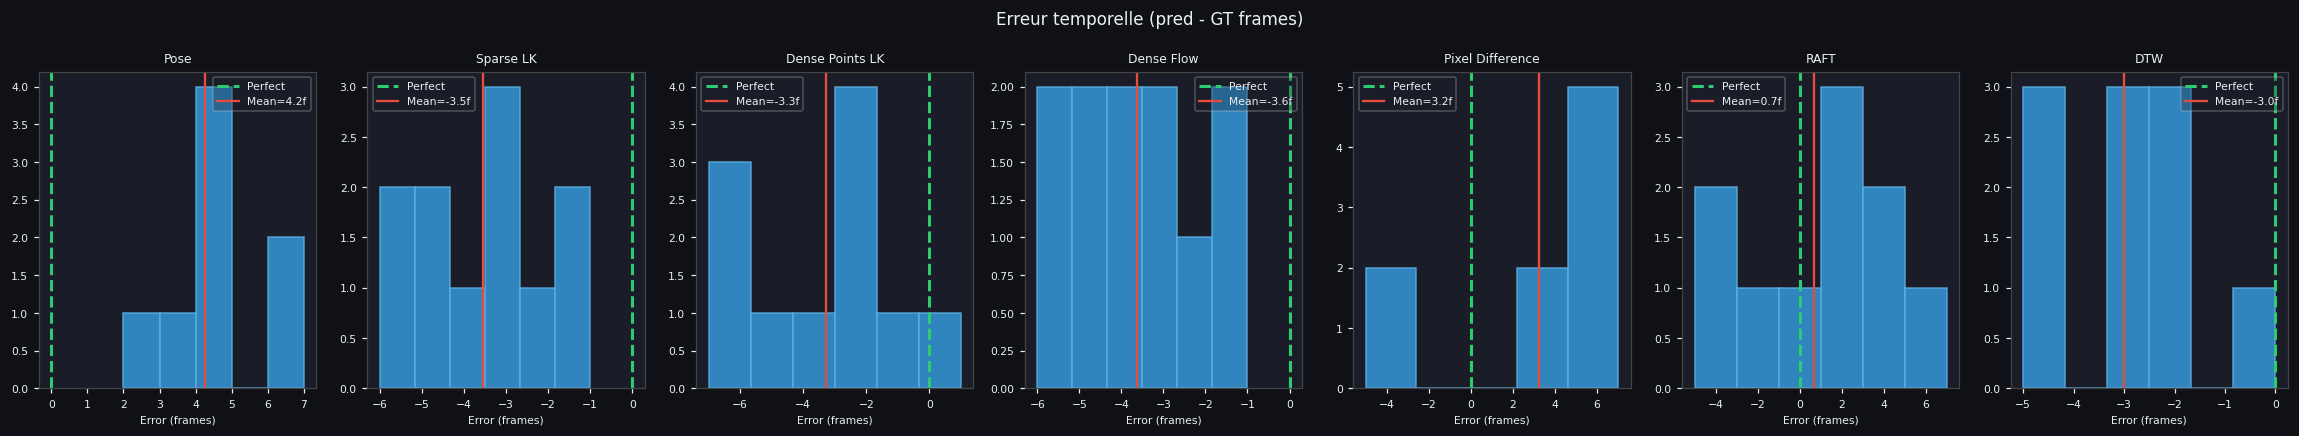

Period=0.483s=29.0f
Méthode                     Err moy        ms  %période
-------------------------------------------------------
RAFT                           +0.7      +12ms      2.4%
DTW                            -3.0      -50ms     10.3%
Pixel Difference               +3.2      +54ms     11.1%
Dense Points LK                -3.3      -55ms     11.3%
Sparse LK                      -3.5      -59ms     12.2%
Dense Flow                     -3.6      -61ms     12.5%
Pose (MediaPipe)               +4.2      +71ms     14.7%


In [69]:
n_ev=len(eval_rows)
fig,axes=plt.subplots(1,n_ev,figsize=(n_ev*3,4))
fig.patch.set_facecolor('#0f1117')
if n_ev==1: axes=[axes]
for ax,ev in zip(axes,eval_rows):
    ax.set_facecolor('#1a1d27')
    errs=[m[2] for m in ev['matches']]
    if errs:
        ax.hist(errs,bins=max(5,len(errs)//2+1),color='#3498db',edgecolor='#5dade2',alpha=0.85)
        ax.axvline(0,color='#2ecc71',lw=2,linestyle='--',label='Perfect')
        ax.axvline(np.mean(errs),color='#e74c3c',lw=1.5,label=f'Mean={np.mean(errs):.1f}f')
        ax.legend(fontsize=7,framealpha=0.3,labelcolor='#ecf0f1',facecolor='#1a1d27')
    ax.set_title(ev['method'].replace('(MediaPipe)','').strip(),color='#ecf0f1',fontsize=8)
    ax.set_xlabel('Error (frames)',color='#ecf0f1',fontsize=7)
    ax.tick_params(colors='#ecf0f1',labelsize=7); ax.spines[:].set_color('#444')
fig.suptitle('Erreur temporelle (pred - GT frames)',color='#ecf0f1',fontsize=11)
plt.tight_layout()
plt.savefig('/content/phase_offset.png',dpi=110,bbox_inches='tight',facecolor=fig.get_facecolor())
plt.show()
print(f'Period={MEAN_PERIOD:.3f}s={MEAN_PERIOD*EFF_FPS:.1f}f')
print(f'{"Méthode":<25}{"Err moy":>10}{"ms":>10}{"%période":>10}')
print('-'*55)
for ev in sorted(eval_rows,key=lambda r:abs(np.mean([m[2] for m in r['matches']]) if r['matches'] else 999)):
    errs=[m[2] for m in ev['matches']]
    if errs:
        me=np.mean(errs)
        print(f"{ev['method'][:24]:<25}{me:>+10.1f}{me/EFF_FPS*1000:>+9.0f}ms{abs(me)/(MEAN_PERIOD*EFF_FPS)*100:>9.1f}%")


## Cellule 16 — Téléchargement des résultats

In [70]:
import shutil
os.makedirs('/content/results',exist_ok=True)
for f in ['evaluation_summary.csv','dashboard.png','roc_auc.png','phase_offset.png']:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}',f'/content/results/{f}')
for key in results:
    src=f'/content/{key}_signal.png'
    if os.path.exists(src): shutil.copy(src,f'/content/results/{key}_signal.png')
shutil.make_archive('/content/benchmark_results','zip','/content/results')
from google.colab import files as _gf2
_gf2.download('/content/benchmark_results.zip')
print('Téléchargé : benchmark_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargé : benchmark_results.zip
